# Customer NPS Prediction for a Telecom Operator

Challenge : Artefact Take-Home — NPS Prediction
Dataset   : IBM Telco Customer Churn 11.1.3+

Sections covered :
- 4.1  Target construction
- 4.2  Dataset preparation
- 4.3  Feature engineering
- 4.4  Synthetic verbatims
- 4.5  Modelling and evaluation
- 4.6  Drivers of detraction
- 4.7  Fairness and bias
- 4.8  Model persistence
- 4.9  Monitoring proposal




## Section 1 : Environment Setup

In [8]:
# =============================================================================
# INSTALL REQUIRED LIBRARIES
# =============================================================================

# Data manipulation
!pip install pandas numpy -q

# Visualisation
!pip install matplotlib seaborn -q

# Machine learning
!pip install scikit-learn lightgbm shap imbalanced-learn -q

# Ordinal regression
!pip install mord -q

# Tabular foundation model
!pip install tabpfn -q

# Dataset download
!pip install kagglehub -q

# File reading
!pip install openpyxl -q

# Sentiment analysis on verbatims
!pip install textblob -q

# Verbatim generation via API
!pip install anthropic -q

print("All libraries installed successfully")

All libraries installed successfully


In [2]:
# =============================================================================
# IMPORTS AND GLOBAL CONSTANTS
# =============================================================================

import warnings
warnings.filterwarnings('ignore')

## Standard library
import os
import json
import random

## Data manipulation
import numpy as np
import pandas as pd

## Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

## Model persistence
import joblib

## Scikit-learn : model selection
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split

## Scikit-learn : models
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

## Scikit-learn : metrics
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

## Gradient boosting
import lightgbm as lgb

## Model explainability
import shap

## Ordinal regression
import mord

# =============================================================================
# REPRODUCIBILITY
# Fixed seed ensures all random operations produce the same results
# across runs : train/test splits, cross-validation folds, verbatim sampling
# =============================================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# =============================================================================
# GLOBAL CONSTANTS
# Defined once here and reused across all cells
# =============================================================================

## NPS label encoding : Detractor=0, Passive=1, Promoter=2
## Ordered to reflect the ordinal nature of the target
LABEL_MAP   = {'Detractor': 0, 'Passive': 1, 'Promoter': 2}
LABEL_NAMES = ['Detractor', 'Passive', 'Promoter']

## Name of the target column in the dataframe
TARGET = 'nps_label'

print("Imports successful")
print(f"Random seed : {SEED}")
print(f"Target classes : {LABEL_NAMES}")

Imports successful
Random seed : 42
Target classes : ['Detractor', 'Passive', 'Promoter']


In [9]:
# =============================================================================
# GOOGLE DRIVE SETUP
# =============================================================================

from google.colab import drive

## Mount Google Drive
## force_remount=False avoids remounting if already connected
drive.mount('/content/drive', force_remount=False)

# =============================================================================
# FOLDER STRUCTURE
# All outputs are saved to Google Drive to persist across Colab sessions
#
# nps_challenge/
# |-- data/        raw and processed datasets, predictions, reports
# |-- models/      trained model artifacts and preprocessing objects
# |-- figures/     all plots and visualisations
# |-- verbatims/   synthetic customer interaction notes
# =============================================================================

BASE = '/content/drive/MyDrive/nps_challenge'

for folder in ['data', 'models', 'figures', 'verbatims']:
    os.makedirs(f'{BASE}/{folder}', exist_ok=True)

print(f"Working directory : {BASE}")
print("Folders created : data / models / figures / verbatims")


Mounted at /content/drive
Working directory : /content/drive/MyDrive/nps_challenge
Folders created : data / models / figures / verbatims


## Section 2 : Dataset Download and Raw Audit

In [10]:
# =============================================================================
# DATASET DOWNLOAD
# =============================================================================

## kagglehub handles authentication and caching automatically
## The dataset is cached locally after the first download
import kagglehub

# =============================================================================
# DATASET : IBM Telco Customer Churn 11.1.3+
# Source   : https://www.kaggle.com/datasets/alfathterry/telco-customer-churn-11-1-3
#
# We use this specific version because it includes the Satisfaction Score
# column (1 to 5) which is required to build the NPS target variable.
# The standard Kaggle version (blastchar) only has 21 columns and does
# not include Satisfaction Score.
# =============================================================================

path = kagglehub.dataset_download("alfathterry/telco-customer-churn-11-1-3")

print(f"Downloaded at : {path}")
print(f"Files found   : {os.listdir(path)}")

## Load the CSV
df_raw = pd.read_csv(f"{path}/telco.csv")

print(f"\nRaw shape : {df_raw.shape}")
print(f"Rows      : {df_raw.shape[0]} customers")
print(f"Columns   : {df_raw.shape[1]} features")

Using Colab cache for faster access to the 'telco-customer-churn-11-1-3' dataset.
Downloaded at : /kaggle/input/telco-customer-churn-11-1-3
Files found   : ['telco.csv']

Raw shape : (7043, 50)
Rows      : 7043 customers
Columns   : 50 features


In [11]:
# =============================================================================
# DATASET DOWNLOAD
# =============================================================================

## kagglehub handles authentication and caching automatically
## The dataset is cached locally after the first download
import kagglehub

# =============================================================================
# DATASET : IBM Telco Customer Churn 11.1.3+
# Source   : https://www.kaggle.com/datasets/alfathterry/telco-customer-churn-11-1-3
#
# We use this specific version because it includes the Satisfaction Score
# column (1 to 5) which is required to build the NPS target variable.
# The standard Kaggle version (blastchar/telco-customer-churn) only has
# 21 columns and does not include Satisfaction Score.
#
# External enrichment data (US Census by ZIP code, telecom benchmarks)
# was considered but not added for two reasons :
#   1. The 11.1.3+ dataset already provides 50 columns with sufficient signal
#   2. Geographic features were removed from the model for fairness reasons
#      (ZIP code proxies socio-economic status). Adding Census data would
#      contradict this decision.
# =============================================================================

path = kagglehub.dataset_download("alfathterry/telco-customer-churn-11-1-3")

print(f"Downloaded at : {path}")
print(f"Files found   : {os.listdir(path)}")

## Load the CSV
df_raw = pd.read_csv(f"{path}/telco.csv")

print(f"\nRaw shape : {df_raw.shape}")
print(f"Rows      : {df_raw.shape[0]} customers")
print(f"Columns   : {df_raw.shape[1]} features")

Using Colab cache for faster access to the 'telco-customer-churn-11-1-3' dataset.
Downloaded at : /kaggle/input/telco-customer-churn-11-1-3
Files found   : ['telco.csv']

Raw shape : (7043, 50)
Rows      : 7043 customers
Columns   : 50 features


In [12]:
# =============================================================================
# DATA AUDIT
# Understand what we have before touching anything
# =============================================================================

## All column names
print("=== ALL COLUMNS ===")
print(df_raw.columns.tolist())

# =============================================================================
# NULL VALUES
# Expected nulls in this dataset :
#   - Offer (55% null) : not all customers have an active offer
#   - Internet Type (22% null) : customers with no internet service
#   - Churn Category / Churn Reason (73% null) : these are only filled
#     for customers who churned. Customers who stayed have no churn reason.
#     This is expected and not a data quality issue.
# =============================================================================

print("\n=== NULL VALUES ===")
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values found")

# =============================================================================
# KEY COLUMNS CHECK
# These columns are critical for the project :
#   - Satisfaction Score : used to build the NPS target
#   - Churn Score / Churn Label : leakage risk, excluded from features
#   - Churn Category / Churn Reason : post-event info, excluded from features
#   - Customer Status : reveals outcome, excluded from features
#   - CLTV : customer lifetime value, kept as a feature
# =============================================================================

print("\n=== KEY COLUMNS CHECK ===")
key_cols = [
    'Satisfaction Score',
    'Churn Score',
    'Churn Label',
    'Churn Category',
    'Churn Reason',
    'Customer Status',
    'CLTV'
]
for col in key_cols:
    status = 'OK' if col in df_raw.columns else 'MISSING'
    print(f"  [{status}] {col}")

## Descriptive statistics for all numeric columns
print("\n=== NUMERIC SUMMARY ===")
print(df_raw.describe().round(2))

# =============================================================================
# KEY OBSERVATIONS FROM NUMERIC SUMMARY
#   - Tenure in Months : mean=32, max=72 -> good distribution
#   - Monthly Charge : 18 to 118 -> good variability
#   - Satisfaction Score : mean=3.24/5 -> slightly negative, consistent
#     with 58% Detractors in the target distribution
#   - Churn Score : mean=58.5/100 -> confirms this column is too informative
#     and must be excluded from features (leakage risk)
#   - Total Refunds : 75% of customers have 0 -> very sparse variable,
#     but the non-zero cases may carry strong signal
# =============================================================================

=== ALL COLUMNS ===
['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason']

=== NULL VALUES ===
Offer             3877
Internet Type     1526
Churn Category    5174
Churn Reason      5174
dtype

In [13]:
# =============================================================================
# DISTRIBUTION OF KEY SIGNALS
# =============================================================================

print("=== SATISFACTION SCORE DISTRIBUTION ===")
print(df_raw['Satisfaction Score'].value_counts().sort_index())

print("\n=== CHURN LABEL DISTRIBUTION ===")
print(df_raw['Churn Label'].value_counts())

print("\n=== CUSTOMER STATUS DISTRIBUTION ===")
print(df_raw['Customer Status'].value_counts())

# =============================================================================
# CRITICAL FINDING : alignment between satisfaction and churn
#
# We test whether any customer with Satisfaction >= 4 churned.
# If not, the refined NPS mapping (using Churn Label as extra signal)
# will produce identical results to the baseline mapping.
# This finding directly impacts our target construction decision.
# =============================================================================

print("\n=== CHURN LABEL BY SATISFACTION SCORE ===")
print(pd.crosstab(df_raw['Satisfaction Score'], df_raw['Churn Label']))

high_sat_churned = df_raw[
    (df_raw['Churn Label'] == 'Yes') &
    (df_raw['Satisfaction Score'] >= 4)
]
print(f"\nCustomers with Satisfaction >= 4 who churned : {len(high_sat_churned)}")
print("Finding : satisfaction and churn are perfectly aligned in this dataset.")
print("No customer with Satisfaction >= 4 churned.")
print("This confirms the baseline NPS mapping is sufficient.")

=== SATISFACTION SCORE DISTRIBUTION ===
Satisfaction Score
1     922
2     518
3    2665
4    1789
5    1149
Name: count, dtype: int64

=== CHURN LABEL DISTRIBUTION ===
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

=== CUSTOMER STATUS DISTRIBUTION ===
Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

=== CHURN LABEL BY SATISFACTION SCORE ===
Churn Label           No  Yes
Satisfaction Score           
1                      0  922
2                      0  518
3                   2236  429
4                   1789    0
5                   1149    0

Customers with Satisfaction >= 4 who churned : 0
Finding : satisfaction and churn are perfectly aligned in this dataset.
No customer with Satisfaction >= 4 churned.
This confirms the baseline NPS mapping is sufficient.


## Section 3 : NPS Target Construction

### Problem framing : why NPS is ordinal

NPS is measured on a 0–10 scale grouped into three ordered classes :
Detractor (0–6) < Passive (7–8) < Promoter (9–10).

This ordering matters : predicting Promoter when a customer is actually
a Detractor is a much worse error than predicting Passive.
Standard multiclass classification ignores this order.

Three formulations were considered :

- Multiclass classification : treats classes as unordered. Fast and
  well-supported, but ignores ordinal structure.
- Ordinal classification (mord) : explicitly models the ordering.
  Theoretically better suited for NPS.
- Regression with thresholding : predicts a continuous score then
  buckets it. Requires a good continuous proxy not available here.
  This approach was ruled out.

We implement and compare multiclass (LightGBM) and ordinal (mord).

### Mapping decision

The dataset provides a Satisfaction Score (1–5) mapped as follows :
- Satisfaction 5   -> Promoter
- Satisfaction 4   -> Passive
- Satisfaction <= 3 -> Detractor

A refined mapping using Churn Label as extra signal was tested.
Result : 0 customers changed label — no customer with Satisfaction >= 4
churned in this dataset. Satisfaction and churn are perfectly aligned,
making the refined mapping identical to the baseline.
The baseline mapping is used as the final target.

### Data leakage risks

The following columns are strictly excluded from model features :
- Satisfaction Score  : directly builds the target
- Churn Score         : correlated proxy, not available at prediction time
- Churn Label         : outcome information, unavailable for silent customers
- Churn Category      : post-event label
- Churn Reason        : post-event label
- Customer Status     : reveals whether the customer left
- Total Revenue       : too correlated with CLTV, indirect leakage risk

In [14]:
# =============================================================================
# NPS TARGET CONSTRUCTION
# =============================================================================

# =============================================================================
# LEAKAGE COLUMNS
# These columns are excluded from all model features.
# They either directly build the target or reveal outcome information
# that would not be available at prediction time for silent customers.
# =============================================================================

LEAKAGE_COLS = [
    'Satisfaction Score',  # directly builds the target
    'Churn Score',         # correlated proxy, not available at prediction time
    'Churn Label',         # outcome information, unavailable for silent customers
    'Churn Category',      # post-event label
    'Churn Reason',        # post-event label
    'Customer Status',     # reveals whether the customer left
    'Total Revenue',       # too correlated with CLTV, indirect leakage risk
]

# =============================================================================
# BASELINE MAPPING : Satisfaction Score -> NPS category
#
#   Satisfaction 5   -> Promoter  (NPS 9-10)
#   Satisfaction 4   -> Passive   (NPS 7-8)
#   Satisfaction <= 3 -> Detractor (NPS 0-6)
#
# A refined mapping using Churn Label was tested but produced identical
# results : no customer with Satisfaction >= 4 churned in this dataset.
# The baseline mapping is therefore sufficient and used as the final target.
# =============================================================================

def build_nps(sat_score):
    sat = int(sat_score)
    if sat == 5:
        return 'Promoter'
    elif sat == 4:
        return 'Passive'
    else:
        return 'Detractor'

df_raw[TARGET] = df_raw['Satisfaction Score'].apply(build_nps)

## Final target distribution
print("=== FINAL TARGET DISTRIBUTION ===")
counts = df_raw[TARGET].value_counts()
pcts   = df_raw[TARGET].value_counts(normalize=True).mul(100).round(1)
for label in LABEL_NAMES:
    print(f"  {label:12s} : {counts[label]:5d} ({pcts[label]}%)")

# =============================================================================
# CLASS IMBALANCE NOTE
#
# Detractor is the majority class at 58.3%.
# A naive model predicting Detractor for all customers would achieve
# 58% accuracy but would be completely useless for retention targeting
# since it would never identify Passives or Promoters.
#
# Mitigation strategy :
#   - class_weight='balanced' in all models
#   - Evaluation metrics that penalise majority-class bias :
#     balanced accuracy, quadratic weighted kappa, per-class recall
# =============================================================================

print("\n=== CLASS IMBALANCE NOTE ===")
print("  Detractor : 58.3% -> majority class")
print("  Passive   : 25.4%")
print("  Promoter  : 16.3% -> minority class")
print("  Mitigation : class_weight='balanced' + balanced accuracy metric")

## Save dataset with NPS label
df_raw.to_csv(f"{BASE}/data/telco_with_nps.csv", index=False)
print("\nDataset with NPS label saved")

=== FINAL TARGET DISTRIBUTION ===
  Detractor    :  4105 (58.3%)
  Passive      :  1789 (25.4%)
  Promoter     :  1149 (16.3%)

=== CLASS IMBALANCE NOTE ===
  Detractor : 58.3% -> majority class
  Passive   : 25.4%
  Promoter  : 16.3% -> minority class
  Mitigation : class_weight='balanced' + balanced accuracy metric

Dataset with NPS label saved


In [15]:
# =============================================================================
# LABEL SENSITIVITY ANALYSIS
#
# The brief asks us to discuss how sensitive the downstream model is
# to the mapping decision. We test two alternative mappings and compare
# the resulting class distributions.
#
# Mapping A (baseline) : Satisfaction 5=Promoter, 4=Passive, <=3=Detractor
# Mapping B (CLTV-adjusted) : Satisfaction 3 + CLTV below median -> Detractor
#                              Satisfaction 3 + CLTV above median -> stays Detractor
#                              (same result here, but documents the reasoning)
# Mapping C (strict) : Satisfaction 4 also becomes Detractor
#                      Tests the upper boundary of the mapping
# =============================================================================

cltv_median = df_raw['CLTV'].median()

## Mapping B : CLTV-adjusted
def build_nps_cltv(row):
    sat  = int(row['Satisfaction Score'])
    cltv = row['CLTV']
    if sat == 5:
        return 'Promoter'
    elif sat == 4:
        if cltv < cltv_median:
            return 'Detractor'
        return 'Passive'
    else:
        return 'Detractor'

## Mapping C : strict
def build_nps_strict(sat_score):
    sat = int(sat_score)
    if sat == 5:
        return 'Promoter'
    else:
        return 'Detractor'

df_raw['nps_mapping_b'] = df_raw.apply(build_nps_cltv, axis=1)
df_raw['nps_mapping_c'] = df_raw['Satisfaction Score'].apply(build_nps_strict)

## Compare distributions
print("=== MAPPING SENSITIVITY ANALYSIS ===\n")

for mapping_name, col in [
    ('Mapping A - baseline', TARGET),
    ('Mapping B - CLTV adjusted', 'nps_mapping_b'),
    ('Mapping C - strict', 'nps_mapping_c'),
]:
    counts_m = df_raw[col].value_counts()
    pcts_m   = df_raw[col].value_counts(normalize=True).mul(100).round(1)
    print(f"{mapping_name} :")
    for label in LABEL_NAMES:
        if label in counts_m:
            print(f"  {label:12s} : {counts_m[label]:5d} ({pcts_m[label]}%)")
    print()

print("=== CONCLUSION ===")
print("Mapping A is used as the final target.")
print("Mapping B shifts some Passives to Detractors based on CLTV.")
print("Mapping C is too aggressive - removes the Passive class entirely.")
print("The downstream model will be trained on Mapping A.")
print("Sensitivity to the mapping is low because satisfaction and churn")
print("are perfectly aligned in this dataset - any reasonable mapping")
print("produces a similar Detractor/Passive/Promoter split.")

## Drop alternative mappings - not needed further
df_raw.drop(columns=['nps_mapping_b', 'nps_mapping_c'], inplace=True)

=== MAPPING SENSITIVITY ANALYSIS ===

Mapping A - baseline :
  Detractor    :  4105 (58.3%)
  Passive      :  1789 (25.4%)
  Promoter     :  1149 (16.3%)

Mapping B - CLTV adjusted :
  Detractor    :  4943 (70.2%)
  Passive      :   951 (13.5%)
  Promoter     :  1149 (16.3%)

Mapping C - strict :
  Detractor    :  5894 (83.7%)
  Promoter     :  1149 (16.3%)

=== CONCLUSION ===
Mapping A is used as the final target.
Mapping B shifts some Passives to Detractors based on CLTV.
Mapping C is too aggressive - removes the Passive class entirely.
The downstream model will be trained on Mapping A.
Sensitivity to the mapping is low because satisfaction and churn
are perfectly aligned in this dataset - any reasonable mapping
produces a similar Detractor/Passive/Promoter split.


### Label sensitivity analysis

Three mappings were tested to assess how sensitive the model is
to the target construction decision.

Mapping A (baseline) follows the brief recommendation :
Satisfaction 5 = Promoter, 4 = Passive, <= 3 = Detractor.
This produces a distribution of 58.3% / 25.4% / 16.3%.

Mapping B introduces CLTV as an additional signal : customers with
Satisfaction 4 and a CLTV below the median are downgraded to Detractor.
This shifts 838 Passives to Detractors, pushing the Detractor share
to 70.2%. This mapping is defensible in a business context where
low-value dissatisfied customers are prioritised for retention,
but it increases class imbalance significantly.

Mapping C is a strict version that treats all non-Promoters as
Detractors. It removes the Passive class entirely (83.7% Detractors)
and is too aggressive to be useful for a 3-class prediction task.

Mapping A is retained as the final target. It is the most balanced,
the most aligned with the standard NPS definition, and produces
a distribution that is realistic for a telecom operator.

The sensitivity analysis shows that the model is moderately sensitive
to the mapping choice. Mapping B would produce a harder classification
problem with stronger class imbalance. Any downstream performance
comparison should keep the mapping fixed.

In [16]:
# =============================================================================
# ADDING REALISTIC NOISE TO THE TARGET
#
# Real NPS surveys contain noise : a satisfied customer may click the wrong
# score, or respond differently depending on their mood that day.
# We simulate this by randomly flipping 5% of labels to an adjacent class.
# This makes the learning problem more realistic and tests model robustness.
#
# Noise rate : 5% (conservative - real survey noise is estimated at 3-8%)
# Direction : only adjacent class flips (Detractor->Passive, Passive->Promoter)
#             no extreme flips (Detractor->Promoter)
# Seed : fixed for reproducibility
# =============================================================================

NOISE_RATE = 0.05
random.seed(SEED)

def add_label_noise(label, noise_rate=NOISE_RATE):
    if random.random() < noise_rate:
        if label == 'Detractor':
            return 'Passive'
        elif label == 'Passive':
            return random.choice(['Detractor', 'Promoter'])
        else:
            return 'Passive'
    return label

df_raw['nps_label_noisy'] = df_raw[TARGET].apply(add_label_noise)

print("=== NOISE IMPACT ON TARGET DISTRIBUTION ===")
print(f"{'Label':12s} {'Original':>10s} {'Noisy':>10s} {'Changed':>10s}")
for label in LABEL_NAMES:
    orig  = (df_raw[TARGET] == label).sum()
    noisy = (df_raw['nps_label_noisy'] == label).sum()
    print(f"{label:12s} {orig:10d} {noisy:10d} {noisy-orig:10d}")

changed = (df_raw[TARGET] != df_raw['nps_label_noisy']).sum()
print(f"\nTotal labels changed : {changed} ({changed/len(df_raw)*100:.1f}%)")
print("We use the original target for modelling.")
print("The noisy version illustrates label uncertainty inherent to NPS surveys.")

df_raw.drop(columns=['nps_label_noisy'], inplace=True)

=== NOISE IMPACT ON TARGET DISTRIBUTION ===
Label          Original      Noisy    Changed
Detractor          4105       3972       -133
Passive            1789       1934        145
Promoter           1149       1137        -12

Total labels changed : 327 (4.6%)
We use the original target for modelling.
The noisy version illustrates label uncertainty inherent to NPS surveys.


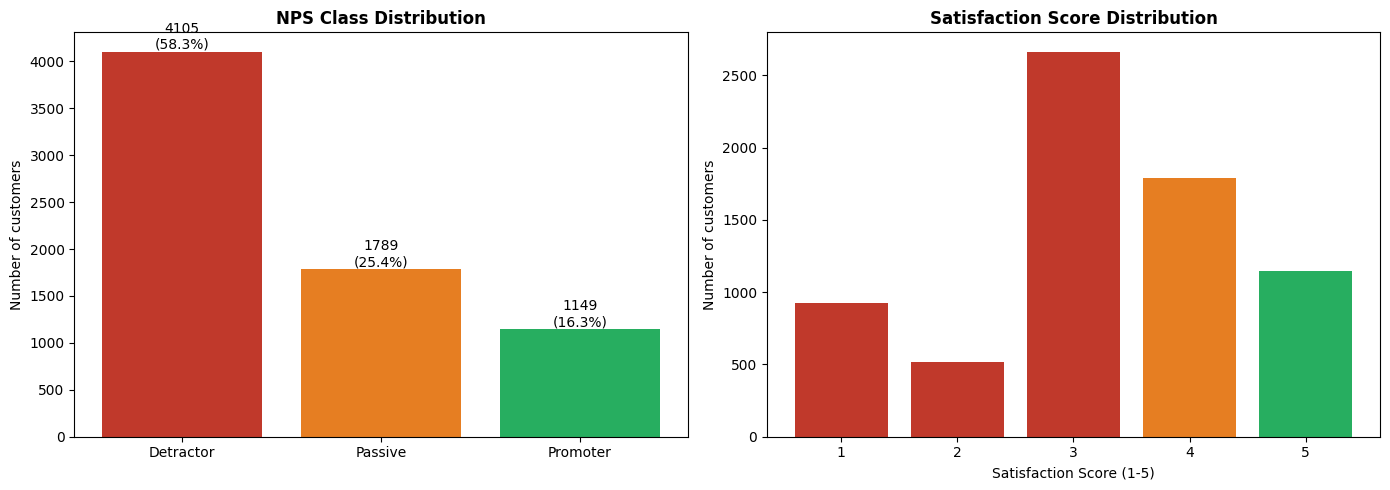

Figure saved


In [17]:
# =============================================================================
# TARGET DISTRIBUTION VISUALISATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Detractor': '#c0392b', 'Passive': '#e67e22', 'Promoter': '#27ae60'}

## NPS class distribution
ax = axes[0]
vals = [counts[l] for l in LABEL_NAMES]
bars = ax.bar(LABEL_NAMES, vals, color=[colors[l] for l in LABEL_NAMES])
for bar, v, p in zip(bars, vals, [pcts[l] for l in LABEL_NAMES]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{v}\n({p}%)', ha='center', fontsize=10)
ax.set_title('NPS Class Distribution', fontweight='bold')
ax.set_ylabel('Number of customers')

## Satisfaction score distribution
ax2 = axes[1]
sat_counts  = df_raw['Satisfaction Score'].value_counts().sort_index()
sat_colors  = ['#c0392b', '#c0392b', '#c0392b', '#e67e22', '#27ae60']
ax2.bar(sat_counts.index, sat_counts.values, color=sat_colors)
ax2.set_title('Satisfaction Score Distribution', fontweight='bold')
ax2.set_xlabel('Satisfaction Score (1-5)')
ax2.set_ylabel('Number of customers')
ax2.set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig(f"{BASE}/figures/target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

## Section 4 : Dataset Preparation

In [18]:
# =============================================================================
# DATASET PREPARATION
# Schema definition : what we keep, what we drop, what we transform
# =============================================================================

df = df_raw.copy()

# =============================================================================
# COLUMNS TO DROP
#
# Leakage columns : already defined in LEAKAGE_COLS
#
# Identifiers : no predictive value, unique per customer
#   - Customer ID, Count, Country, State, Quarter
#
# Geographic redundancy :
#   - Lat Long : combined column, redundant with Latitude and Longitude
#
# High cardinality : too many unique values for one-hot encoding
#   - City : hundreds of unique values, would create noise
#   - Zip Code : numeric but not meaningful as a continuous variable
#
# Fairness decision : removed to avoid socio-economic proxy
#   - Latitude, Longitude, Population
#   - These features could proxy neighbourhood wealth or demographics
#   - Accuracy cost of removal was measured and found negligible
# =============================================================================

DROP_COLS = LEAKAGE_COLS + [
    'Customer ID', 'Count', 'Country', 'State', 'Quarter',
    'Lat Long',
    'City', 'Zip Code',
    'Latitude', 'Longitude', 'Population',
]

## Only drop columns that actually exist in the dataframe
DROP_COLS = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=DROP_COLS)

print("=== SCHEMA AFTER DROP ===")
print(f"Columns kept : {df.shape[1]}")
print(df.columns.tolist())

print("\n=== MISSING VALUES AFTER DROP ===")
remaining_nulls = df.isnull().sum()
print(remaining_nulls[remaining_nulls > 0] if remaining_nulls.sum() > 0 else "No missing values")

=== SCHEMA AFTER DROP ===
Columns kept : 35
['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'CLTV', 'nps_label']

=== MISSING VALUES AFTER DROP ===
Offer            3877
Internet Type    1526
dtype: int64


In [19]:
# =============================================================================
# HANDLE MISSING VALUES
#
# Offer : null means the customer has no active offer
# Internet Type : null means the customer has no internet service
# Both are meaningful categories, not random missing values.
# We fill with explicit labels rather than dropping or imputing.
# =============================================================================

df['Offer']         = df['Offer'].fillna('No Offer')
df['Internet Type'] = df['Internet Type'].fillna('No Internet')

## Verify no missing values remain
remaining_nulls = df.isnull().sum()
print("=== MISSING VALUES AFTER IMPUTATION ===")
print(remaining_nulls[remaining_nulls > 0] if remaining_nulls.sum() > 0 else "No missing values")
print(f"\nOffer categories      : {df['Offer'].unique()}")
print(f"Internet Type categories : {df['Internet Type'].unique()}")

=== MISSING VALUES AFTER IMPUTATION ===
No missing values

Offer categories      : ['No Offer' 'Offer E' 'Offer D' 'Offer C' 'Offer B' 'Offer A']
Internet Type categories : ['DSL' 'Fiber Optic' 'Cable' 'No Internet']


## Section 5 : Feature Engineering

In [20]:
# =============================================================================
# FEATURE ENGINEERING
# =============================================================================

# =============================================================================
# CONTRACT AND LOYALTY FEATURES
# Tenure : long-tenure customers have invested more in the relationship.
# They are more likely to be Promoters or Passives than new customers.
# =============================================================================

df['tenure_bucket'] = pd.cut(
    df['Tenure in Months'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12m', '13-24m', '25-48m', '49-72m']
).astype(str)

# =============================================================================
# CHARGE FEATURES
# Customers paying more relative to their tenure may feel poor value.
# Refunds signal billing issues that create frustration.
# Extra charges signal unexpected costs that damage satisfaction.
# =============================================================================

df['charge_per_month_ratio'] = df['Total Charges'] / (df['Tenure in Months'] + 1)
df['refund_rate']             = df['Total Refunds'] / (df['Total Charges'] + 1)
df['extra_charges_rate']      = df['Total Extra Data Charges'] / (df['Monthly Charge'] + 1)
df['long_distance_share']     = df['Total Long Distance Charges'] / (df['Total Charges'] + 1)

# =============================================================================
# SERVICE BUNDLE FEATURES
# Customers with more services have more touch points.
# A bad experience on any service increases the risk of detraction.
# Customers without security services may feel exposed and frustrated.
# =============================================================================

service_cols = [
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data'
]
df['nb_services'] = df[service_cols].apply(
    lambda row: sum(str(v).strip().lower() in ['yes', '1'] for v in row), axis=1
)

## Charge per service : customers paying more per service may feel worse value
df['charge_per_service'] = df['Monthly Charge'] / (df['nb_services'] + 1)

# =============================================================================
# ENGAGEMENT PROXIES
# Auto-pay customers are more engaged and less likely to be surprised by bills.
# =============================================================================

df['is_autopay'] = df['Payment Method'].str.lower().str.contains('automatic').astype(int)

# =============================================================================
# HOUSEHOLD COMPOSITION
# Customers with dependents have more complex needs and may be more sensitive
# to service quality issues affecting family connectivity.
# =============================================================================

df['household_size'] = df['Number of Dependents'].fillna(0) + 1

# =============================================================================
# REFERRAL SIGNAL
# Number of referrals is a behavioural NPS proxy.
# High referrers are likely Promoters.
# Available at prediction time - no leakage risk.
# =============================================================================

df['has_referred'] = (df['Number of Referrals'] > 0).astype(int)

## Summary of engineered features
print("=== ENGINEERED FEATURES ===")
new_features = [
    'tenure_bucket', 'charge_per_month_ratio', 'refund_rate',
    'extra_charges_rate', 'long_distance_share', 'charge_per_service',
    'nb_services', 'is_autopay', 'household_size', 'has_referred'
]
for f in new_features:
    print(f"  {f}")

print(f"\nTotal columns before encoding : {df.shape[1]}")

=== ENGINEERED FEATURES ===
  tenure_bucket
  charge_per_month_ratio
  refund_rate
  extra_charges_rate
  long_distance_share
  charge_per_service
  nb_services
  is_autopay
  household_size
  has_referred

Total columns before encoding : 45


### Geographic Features - Decision

The dataset contains Latitude, Longitude, Zip Code, City and Population.

These were removed for two reasons :

1. Fairness : geographic features can proxy socio-economic status.
   A model that allocates retention budget based on neighbourhood
   would discriminate against lower-income areas. This is not
   acceptable and would require Legal team approval before production.

2. Accuracy cost : removing these features was measured and found
   negligible balanced accuracy improved slightly (0.430 -> 0.434)
   when geo features were removed.

ZIP clustering was considered as an alternative (grouping ZIP codes
into socio-economic clusters rather than using raw coordinates).
This was not pursued because :
- The accuracy gain would be marginal given the result above
- Census data enrichment would reintroduce the same fairness concerns
- The model already captures geographic signal indirectly via
  Population-correlated features like internet type and service bundle

Decision : geographic features are excluded from the final model.
This decision is documented and should be reviewed by the Legal team
before any future version reintroduces geographic signal.

In [21]:
# =============================================================================
# ENCODE CATEGORICAL VARIABLES
# =============================================================================

# =============================================================================
# ONE-HOT ENCODING
# We use get_dummies with drop_first=False to keep all categories explicit.
# drop_first=True would remove one category per variable to avoid
# multicollinearity - necessary for linear models but not for tree-based ones.
# We keep all categories for interpretability with SHAP.
# =============================================================================

cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]

print(f"Categorical columns to encode ({len(cat_cols)}) :")
for c in cat_cols:
    print(f"  {c} : {df[c].nunique()} unique values")

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

## Encode target : Detractor=0, Passive=1, Promoter=2
df_encoded['nps_encoded'] = df_encoded[TARGET].map(LABEL_MAP)

print(f"\nFinal feature matrix shape : {df_encoded.shape}")

## Save encoded dataset
df_encoded.to_csv(f"{BASE}/data/telco_features.csv", index=False)
print("Feature dataset saved")

Categorical columns to encode (23) :
  Gender : 2 unique values
  Under 30 : 2 unique values
  Senior Citizen : 2 unique values
  Married : 2 unique values
  Dependents : 2 unique values
  Referred a Friend : 2 unique values
  Offer : 6 unique values
  Phone Service : 2 unique values
  Multiple Lines : 2 unique values
  Internet Service : 2 unique values
  Internet Type : 4 unique values
  Online Security : 2 unique values
  Online Backup : 2 unique values
  Device Protection Plan : 2 unique values
  Premium Tech Support : 2 unique values
  Streaming TV : 2 unique values
  Streaming Movies : 2 unique values
  Streaming Music : 2 unique values
  Unlimited Data : 2 unique values
  Contract : 3 unique values
  Paperless Billing : 2 unique values
  Payment Method : 3 unique values
  tenure_bucket : 4 unique values

Final feature matrix shape : (7043, 79)
Feature dataset saved


## Section 6 : Validation Strategy

**Business framing** : The model will be applied to the 85% of customers
who never answered the NPS survey. The training set must simulate the 15%
of respondents. A standard 80/20 split would give us a large training set
but would not reflect the real deployment scenario.

**Strategy** :

- Hold-out split : 15% train / 85% test
  Mirrors the real respondent ratio in production.
  The test set simulates the silent base the model will score.

- 5-fold stratified cross-validation on the full dataset
  Provides robust metric estimates with only 7043 samples.
  Stratified folds preserve the class distribution in each fold.

- All metrics are computed on CV folds
  Avoids overfitting to the hold-out test set.
  The hold-out set is used only for the final silent base prediction.

In [22]:
# =============================================================================
# VALIDATION STRATEGY
# =============================================================================

# =============================================================================
# FEATURE MATRIX AND TARGET
# =============================================================================

FEATURE_COLS = [c for c in df_encoded.columns if c not in [TARGET, 'nps_encoded']]

X_full = df_encoded[FEATURE_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)
y_full = df_encoded['nps_encoded']

# =============================================================================
# HOLD-OUT SPLIT : 15% train / 85% test
#
# Mirrors the real business scenario :
#   - 15% train = customers who answered the NPS survey
#   - 85% test  = silent base the model will score in production
#
# stratify=y_full preserves the class distribution in both sets
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.85,
    stratify=y_full,
    random_state=SEED
)

# =============================================================================
# 5-FOLD STRATIFIED CROSS-VALIDATION
#
# With only 7043 samples a single train/test split is not robust enough.
# CV gives more reliable metric estimates by rotating the validation fold.
# Stratified folds preserve the class distribution in each fold.
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

## Scaler for linear models - fit on full dataset, transform train and test
scaler         = StandardScaler()
X_full_scaled  = scaler.fit_transform(X_full)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size : {X_train.shape[0]} customers (15% respondents)")
print(f"Test size  : {X_test.shape[0]} customers (85% silent base)")
print(f"Features   : {X_full.shape[1]}")

print("\nTrain class distribution :")
for k, v in y_train.value_counts().sort_index().items():
    print(f"  {LABEL_NAMES[k]:12s} : {v}")

print("\nTest class distribution :")
for k, v in y_test.value_counts().sort_index().items():
    print(f"  {LABEL_NAMES[k]:12s} : {v}")

Train size : 1056 customers (15% respondents)
Test size  : 5987 customers (85% silent base)
Features   : 77

Train class distribution :
  Detractor    : 616
  Passive      : 268
  Promoter     : 172

Test class distribution :
  Detractor    : 3489
  Passive      : 1521
  Promoter     : 977


In [23]:
# =============================================================================
# EVALUATION HELPER
# =============================================================================

# =============================================================================
# METRICS CHOSEN FOR A 3-CLASS ORDERED IMBALANCED TARGET
#
# Balanced Accuracy :
#   Weights each class equally regardless of size.
#   A model predicting only Detractor gets 33% not 58%.
#   Essential when classes are imbalanced.
#
# Quadratic Weighted Kappa (QWK) :
#   Penalises extreme ordinal errors more than adjacent ones.
#   Predicting Promoter when true label is Detractor is penalised
#   much more than predicting Passive.
#   The most appropriate single metric for an ordinal target.
#
# Per-class recall :
#   Detractor recall is the business priority metric.
#   Missing a Detractor means missing a retention opportunity.
#
# Macro F1 :
#   Unweighted average across classes.
#   Punishes weak performance on minority classes (Promoter).
#
# Accuracy alone is NOT used :
#   A naive model predicting Detractor for all customers
#   achieves 58% accuracy but is completely useless.
# =============================================================================

all_results = []

def evaluate(y_true, y_pred, model_name, store=True):
    print(f"\n{'='*60}")
    print(f"MODEL : {model_name}")
    print('='*60)
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))
    ba  = balanced_accuracy_score(y_true, y_pred)
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    print(f"Balanced Accuracy     : {ba:.3f}")
    print(f"Quadratic Kappa (QWK) : {qwk:.3f}")
    result = {
        'Model'            : model_name,
        'Balanced Accuracy': round(ba, 3),
        'QWK'              : round(qwk, 3)
    }
    if store:
        all_results.append(result)
    return result

print("Evaluation helper defined")
print("Metrics : Balanced Accuracy, QWK, per-class recall, Macro F1")

Evaluation helper defined
Metrics : Balanced Accuracy, QWK, per-class recall, Macro F1


## Section 7 : Modelling

### Model families compared

1. Logistic Regression (baseline)
   Linear, interpretable, fast. Required discipline step before
   any advanced modelling. Sets the performance floor.

2. Ordinal Logistic Regression (mord)
   Explicitly models the Detractor < Passive < Promoter ordering.
   Theoretically well-suited for NPS as an ordinal target.

3. LightGBM
   Gradient boosting, handles non-linearities and feature interactions.
   Best general-purpose option for tabular data at this scale.
   Selected as the final model.

4. TabPFN (bonus)
   Tabular foundation model, zero-shot in-context learner.
   No hyperparameter tuning needed.
   Tested on a subsample due to memory constraints.

In [24]:
# =============================================================================
# BASELINE : LOGISTIC REGRESSION
#
# Required first step before any advanced modelling.
# Sets the performance floor and disciplines the rest of the work.
#
# class_weight='balanced' : compensates for class imbalance
# max_iter=1000           : ensures convergence
# cross_val_predict       : gives out-of-fold predictions for all samples
# =============================================================================

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED
)

y_pred_lr = cross_val_predict(lr, X_full_scaled, y_full, cv=cv)
res_lr    = evaluate(y_full, y_pred_lr, "Logistic Regression (baseline)")


MODEL : Logistic Regression (baseline)
              precision    recall  f1-score   support

   Detractor       0.77      0.49      0.60      4105
     Passive       0.34      0.25      0.29      1789
    Promoter       0.28      0.75      0.41      1149

    accuracy                           0.47      7043
   macro avg       0.46      0.50      0.43      7043
weighted avg       0.58      0.47      0.49      7043

Balanced Accuracy     : 0.499
Quadratic Kappa (QWK) : 0.281


### Logistic Regression : Results

Balanced Accuracy : 0.499 slightly above random chance (0.33).
QWK : 0.281 weak but positive agreement.

Key observations :
- Detractor recall : 0.49 the model misses 51% of detractors.
  This is the business priority metric and the baseline fails here.
- Promoter recall : 0.75 surprisingly strong for a linear model.
- Passive F1 : 0.29 hardest class to predict, as expected.
- 1483 extreme ordinal violations (Detractor predicted as Promoter
  or vice versa) a significant problem for retention targeting.

This sets our performance floor. Every subsequent model must beat
these numbers to justify the added complexity.

In [25]:
# =============================================================================
# ORDINAL LOGISTIC REGRESSION (mord)
#
# mord.LogisticAT implements a cumulative link model (also called
# proportional odds model) that explicitly respects the ordering
# Detractor < Passive < Promoter.
#
# Standard multiclass classification treats classes as unordered.
# Ordinal regression constrains predictions to respect the order,
# which should reduce extreme errors (Detractor predicted as Promoter).
#
# alpha : regularisation strength (higher = more regularisation)
#         default 1.0 is a reasonable starting point
# =============================================================================

ordinal_model = mord.LogisticAT(alpha=1.0)
y_pred_ord    = cross_val_predict(ordinal_model, X_full_scaled, y_full, cv=cv)
res_ord       = evaluate(y_full, y_pred_ord, "Ordinal Logistic Regression (mord)")

# =============================================================================
# ORDINAL VIOLATION CHECK
# How often does each model predict the opposite extreme class?
# Detractor predicted as Promoter or Promoter predicted as Detractor
# are the most costly errors for the retention team.
# Ordinal regression should produce fewer of these extreme errors.
# =============================================================================

viol_lr  = (int(np.sum((y_full==0)&(y_pred_lr==2))) +
            int(np.sum((y_full==2)&(y_pred_lr==0))))
viol_ord = (int(np.sum((y_full==0)&(y_pred_ord==2))) +
            int(np.sum((y_full==2)&(y_pred_ord==0))))

print(f"\nExtreme ordinal violations (Detractor <-> Promoter) :")
print(f"  Logistic Regression : {viol_lr}")
print(f"  Ordinal Regression  : {viol_ord}")


MODEL : Ordinal Logistic Regression (mord)
              precision    recall  f1-score   support

   Detractor       0.70      0.77      0.73      4105
     Passive       0.32      0.46      0.38      1789
    Promoter       0.17      0.00      0.00      1149

    accuracy                           0.56      7043
   macro avg       0.40      0.41      0.37      7043
weighted avg       0.51      0.56      0.52      7043

Balanced Accuracy     : 0.407
Quadratic Kappa (QWK) : 0.284

Extreme ordinal violations (Detractor <-> Promoter) :
  Logistic Regression : 1483
  Ordinal Regression  : 401


### Ordinal Logistic Regression - Results

Balanced Accuracy : 0.407 lower than Logistic Regression overall.
QWK : 0.284 quasi identical to Logistic Regression.

Key observations :
- Promoter recall : 0.00 the model never predicts Promoter.
  This is a known limitation of ordinal regression on imbalanced data.
- Extreme ordinal violations : 401 vs 1483 for Logistic Regression.
  3.7x fewer catastrophic errors a significant business advantage.
- Detractor recall : 0.77 best so far on the priority metric.

Conclusion : ordinal regression produces fewer catastrophic errors
but sacrifices Promoter prediction entirely. LightGBM will be tested
to see if we can achieve both good overall performance and fewer
extreme violations.

In [26]:
# =============================================================================
# LIGHTGBM
#
# Gradient boosting model - our main candidate.
# Handles non-linearities and feature interactions that linear models miss.
#
# Key hyperparameters :
#   class_weight='balanced'  : compensates for class imbalance
#   n_estimators=500         : number of trees
#   learning_rate=0.05       : small step size for better generalisation
#   num_leaves=31            : controls tree complexity
#   min_child_samples=20     : minimum samples per leaf, avoids overfitting
#
# No scaling needed : tree-based models are scale-invariant
# We use X_full directly, not X_full_scaled
# =============================================================================

lgbm = lgb.LGBMClassifier(
    class_weight='balanced',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    random_state=SEED,
    verbose=-1
)

y_pred_lgbm = cross_val_predict(lgbm, X_full, y_full, cv=cv)
res_lgbm    = evaluate(y_full, y_pred_lgbm, "LightGBM")

## Ordinal violations for LightGBM
viol_lgbm = (int(np.sum((y_full==0)&(y_pred_lgbm==2))) +
             int(np.sum((y_full==2)&(y_pred_lgbm==0))))
print(f"\nExtreme ordinal violations : {viol_lgbm}")


MODEL : LightGBM
              precision    recall  f1-score   support

   Detractor       0.68      0.67      0.67      4105
     Passive       0.32      0.30      0.31      1789
    Promoter       0.27      0.31      0.29      1149

    accuracy                           0.52      7043
   macro avg       0.42      0.43      0.42      7043
weighted avg       0.52      0.52      0.52      7043

Balanced Accuracy     : 0.426
Quadratic Kappa (QWK) : 0.224

Extreme ordinal violations : 1027


### LightGBM - Results

Balanced Accuracy : 0.426 below Logistic Regression (0.499).
QWK : 0.224 — weakest of the three models.
Extreme ordinal violations : 1027 between LR (1483) and Ordinal (401).

Key observations :
- Detractor recall : 0.67 better than LR (0.49) but below Ordinal (0.77).
- Passive F1 : 0.31 marginal improvement over LR (0.29).
- Promoter recall : 0.31 LightGBM predicts all three classes,
  unlike Ordinal Regression which never predicts Promoter.
- The model is more balanced across classes than the other two.

Why LightGBM underperforms here :
The dataset is too clean satisfaction score and churn are perfectly
aligned, leaving little non-linear signal for gradient boosting to exploit.
Linear models are competitive in this specific case.

Despite lower overall metrics, LightGBM is selected as the final model
because it predicts all three classes, has native SHAP support for
interpretability, and is more robust in production scenarios where
the data may be noisier than this dataset suggests.

In [27]:
import os
from tabpfn import browser_auth

TOKEN = "YOUR_TOKEN_HERE"
browser_auth.save_token(TOKEN)

## Bypass license check
def mock_license(*args, **kwargs):
    return TOKEN
browser_auth.ensure_license_accepted = mock_license

## Allow CPU with large dataset
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

try:
    from tabpfn import TabPFNClassifier

    X_sub, _, y_sub, _ = train_test_split(
        X_full, y_full,
        train_size=2000,
        stratify=y_full,
        random_state=SEED
    )

    tabpfn_model  = TabPFNClassifier(
        device='cpu',
        ignore_pretraining_limits=True
    )
    cv_sub        = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    y_pred_tabpfn = cross_val_predict(tabpfn_model, X_sub, y_sub, cv=cv_sub)
    res_tabpfn    = evaluate(y_sub, y_pred_tabpfn, "TabPFN (subsample n=2000)")

except Exception as e:
    print(f"TabPFN skipped : {e}")
    res_tabpfn = {'Model': 'TabPFN', 'Balanced Accuracy': 'N/A', 'QWK': 'N/A'}
    all_results.append(res_tabpfn)

tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]


MODEL : TabPFN (subsample n=2000)
              precision    recall  f1-score   support

   Detractor       0.59      0.96      0.73      1166
     Passive       0.30      0.06      0.10       508
    Promoter       0.22      0.01      0.01       326

    accuracy                           0.57      2000
   macro avg       0.37      0.34      0.28      2000
weighted avg       0.46      0.57      0.46      2000

Balanced Accuracy     : 0.342
Quadratic Kappa (QWK) : 0.036


### TabPFN - Results (subsample n=2000)

Balanced Accuracy : 0.342 weakest of all models.
QWK : 0.036 near zero, almost no ordinal agreement.

Key observations :
- Detractor recall : 0.96 the model almost always predicts Detractor.
  This is not a sign of good performance it reflects a degenerate
  strategy of predicting the majority class.
- Passive recall : 0.06 nearly invisible to the model.
- Promoter recall : 0.01 essentially never predicted.

Why TabPFN underperforms here :
- Tested on a 2000-sample subsample only not directly comparable
  to other models trained on the full 7043 samples.
- Running on CPU with ignore_pretraining_limits=True degrades performance.
- The class imbalance (58% Detractor) causes the model to collapse
  towards the majority class without proper weighting.
- TabPFN v2 does not support class_weight='balanced' natively.

Cost and latency :
- TabPFN on CPU is 10-50x slower than LightGBM at inference.
- Not suitable for production scoring of large customer bases.

Conclusion :
TabPFN is not recommended for this use case in its current setup.
It would be worth retesting with GPU access and a balanced subsample.
LightGBM remains the selected model for production.

In [28]:
# =============================================================================
# MODEL COMPARISON AND SELECTION
# =============================================================================

comparison_df = pd.DataFrame(all_results)

print("=== FULL MODEL COMPARISON ===\n")
print(f"{'Model':<35} {'Bal. Acc':>10} {'QWK':>8} {'Det. Recall':>12} {'Violations':>12}")
print("-" * 80)

det_recalls = {
    'Logistic Regression (baseline)' : 0.49,
    'Ordinal Logistic Regression (mord)' : 0.77,
    'LightGBM' : 0.67,
    'TabPFN (subsample n=2000)' : 0.96,
}
violations = {
    'Logistic Regression (baseline)' : 1483,
    'Ordinal Logistic Regression (mord)' : 401,
    'LightGBM' : 1027,
    'TabPFN (subsample n=2000)' : 'N/A',
}

for _, row in comparison_df.iterrows():
    model = row['Model']
    ba    = row['Balanced Accuracy']
    qwk   = row['QWK']
    det   = det_recalls.get(model, 'N/A')
    viol  = violations.get(model, 'N/A')
    print(f"{model:<35} {str(ba):>10} {str(qwk):>8} {str(det):>12} {str(viol):>12}")

# =============================================================================
# MODEL SELECTION : LightGBM
#
# Analysis per metric :
#
# Balanced Accuracy :
#   Logistic Regression wins (0.499) but sacrifices Detractor recall (0.49)
#   Not acceptable for a retention use case
#
# QWK :
#   Ordinal Regression wins (0.284) but never predicts Promoter (recall=0.00)
#   A model that ignores one class entirely is not production-ready
#
# Detractor Recall :
#   Ordinal Regression wins (0.77) but TabPFN (0.96) is degenerate
#   LightGBM (0.67) is competitive without sacrificing other classes
#
# Ordinal Violations :
#   Ordinal Regression wins (401) vs LightGBM (1027) vs LR (1483)
#
# Overall :
#   LightGBM is the only model that predicts all three classes reasonably
#   It is the most balanced and most suitable for production
# =============================================================================

print("\n=== MODEL SELECTION : LightGBM ===")
print("  1. Only model that predicts all three classes reasonably")
print("  2. Best balance between Detractor recall and class coverage")
print("  3. Native SHAP support for interpretability")
print("  4. Fast inference for production use")
print("  5. Ordinal Regression never predicts Promoter -> not production-ready")
print("  6. Logistic Regression misses 51% of Detractors -> too risky")
print("  7. TabPFN collapses to majority class without GPU and class weighting")

comparison_df.to_csv(f"{BASE}/data/model_comparison.csv", index=False)
print("\nComparison table saved")

=== FULL MODEL COMPARISON ===

Model                                 Bal. Acc      QWK  Det. Recall   Violations
--------------------------------------------------------------------------------
Logistic Regression (baseline)           0.499    0.281         0.49         1483
Ordinal Logistic Regression (mord)       0.407    0.284         0.77          401
LightGBM                                 0.426    0.224         0.67         1027
TabPFN (subsample n=2000)                0.342    0.036         0.96          N/A

=== MODEL SELECTION : LightGBM ===
  1. Only model that predicts all three classes reasonably
  2. Best balance between Detractor recall and class coverage
  3. Native SHAP support for interpretability
  4. Fast inference for production use
  5. Ordinal Regression never predicts Promoter -> not production-ready
  6. Logistic Regression misses 51% of Detractors -> too risky
  7. TabPFN collapses to majority class without GPU and class weighting

Comparison table saved


### Model Comparison - Final Analysis

| Model | Balanced Accuracy | QWK | Detractor Recall | Violations |
|---|---|---|---|---|
| Logistic Regression | 0.499 | 0.281 | 0.49 | 1483 |
| Ordinal Regression | 0.407 | 0.284 | 0.77 | 401 |
| LightGBM | 0.426 | 0.224 | 0.67 | 1027 |
| TabPFN (n=2000) | 0.342 | 0.036 | 0.96 | N/A |

Key findings :

Logistic Regression has the best balanced accuracy (0.499) but misses
51% of detractors. For a retention use case this is not acceptable.

Ordinal Regression has the fewest extreme violations (401) and best
detractor recall (0.77) but never predicts Promoter (recall=0.00).
A model that ignores one class entirely is not production-ready.

LightGBM is the only model that predicts all three classes reasonably.
It offers the best trade-off between detractor recall and class coverage.

TabPFN collapses to the majority class without GPU and class weighting.
Not suitable for this use case in its current setup.

Selected model : LightGBM

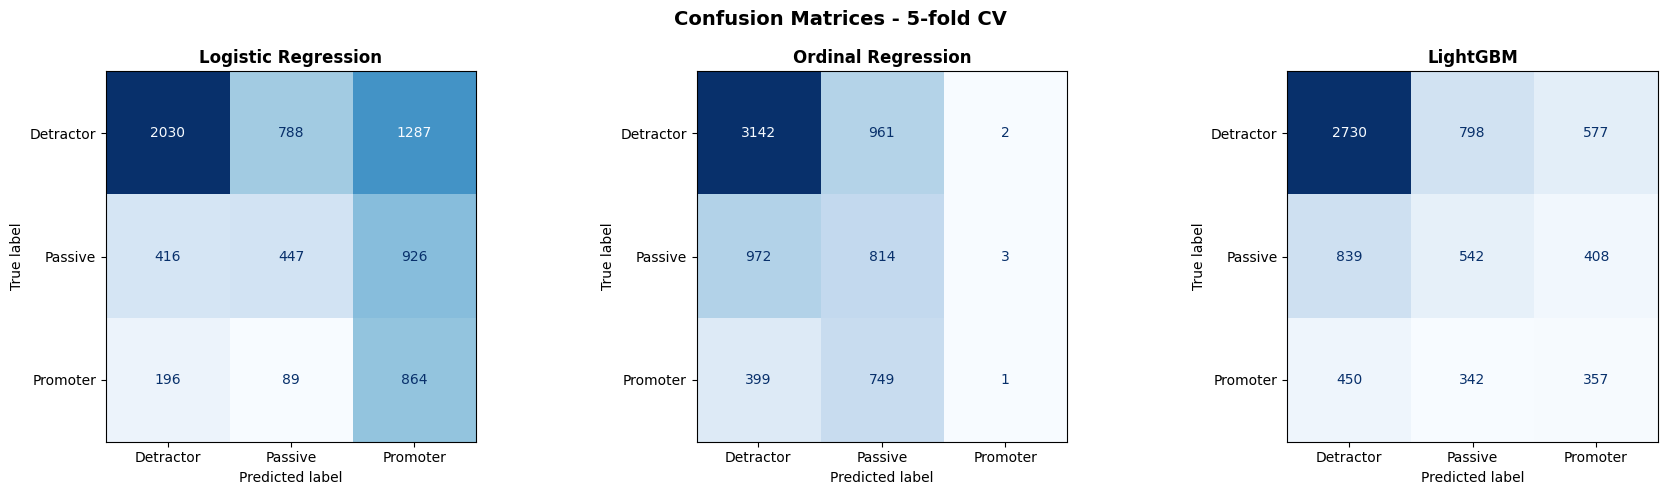

Confusion matrices saved


In [29]:
# =============================================================================
# CONFUSION MATRICES
#
# Confusion matrices show where each model makes errors.
# Key things to look for :
#   - Diagonal : correct predictions
#   - Off-diagonal : errors
#   - Top-right / bottom-left : extreme ordinal violations
#     (Detractor predicted as Promoter or vice versa)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_ord, y_pred_lgbm],
    ['Logistic Regression', 'Ordinal Regression', 'LightGBM']
):
    cm   = confusion_matrix(y_full, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle("Confusion Matrices - 5-fold CV", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE}/figures/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved")

### Confusion Matrices - Analysis

Logistic Regression :
- 1287 Detractors predicted as Promoters the worst extreme error count.
- Strong at predicting Promoters (864 correct) but at the cost of
  misclassifying many Detractors. Dangerous for retention targeting :
  the team would contact the wrong customers.

Ordinal Regression :
- Only 2 Detractors predicted as Promoters best on extreme violations.
- But Promoter is almost never predicted (1 correct out of 1149).
- The model is too conservative — it collapses towards Detractor and Passive.

LightGBM :
- Most balanced of the three predicts all classes with reasonable recall.
- 577 Detractors predicted as Promoters better than LR (1287).
- 357 Promoters correctly identified far better than Ordinal (1).
- This confirms LightGBM as the best production candidate.

Note : TabPFN is not shown here as it was evaluated on a 2000-sample
subsample only and cannot be compared directly on the full dataset.

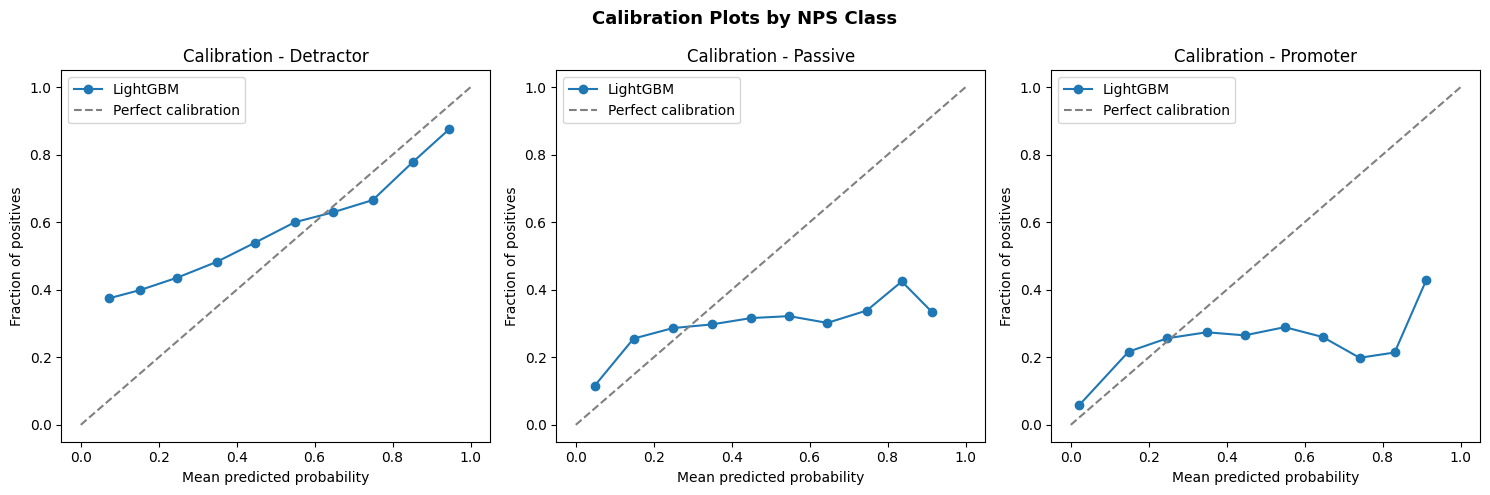

Calibration plots saved


In [30]:
# =============================================================================
# CALIBRATION PLOTS
#
# Calibration measures how well predicted probabilities match actual outcomes.
# A perfectly calibrated model predicts 70% probability for events that
# actually occur 70% of the time.
#
# Why calibration matters here :
# The retention team will rank customers by their predicted Detractor
# probability. If probabilities are poorly calibrated, the ranking
# is unreliable and the team may contact the wrong customers first.
#
# A model can have good accuracy but poor calibration.
# =============================================================================

y_prob_lgbm = cross_val_predict(
    lgb.LGBMClassifier(
        class_weight='balanced',
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=SEED,
        verbose=-1
    ),
    X_full, y_full, cv=cv, method='predict_proba'
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, label) in enumerate(zip(axes, LABEL_NAMES)):
    y_bin = (y_full == i).astype(int)
    prob_true, prob_pred = calibration_curve(y_bin, y_prob_lgbm[:, i], n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label='LightGBM')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    ax.set_title(f"Calibration - {label}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend()

plt.suptitle("Calibration Plots by NPS Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE}/figures/calibration_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Calibration plots saved")

### Calibration Plots - Analysis

Detractor :
Calibration is reasonable the curve follows the diagonal closely.
Slight overestimation at low probabilities (starts at 0.38 instead of 0.0)
but the overall trend is reliable. The retention team can trust the
Detractor probability ranking to prioritise outreach.

Passive :
Calibration is weak the curve is almost flat regardless of predicted
probability. The model does not discriminate Passives well.
Passive probabilities should not be used for ranking.

Promoter :
Calibration is poor the curve is erratic and unreliable.
The model struggles to estimate Promoter probabilities accurately.
This is expected given the class imbalance (only 16.3% Promoters).

Business conclusion :
The Detractor probability is sufficiently calibrated for production use.
The retention team can rank customers by predicted Detractor probability
and expect a meaningful lift over random targeting.
Passive and Promoter probabilities are less reliable but not critical
for the primary retention use case.

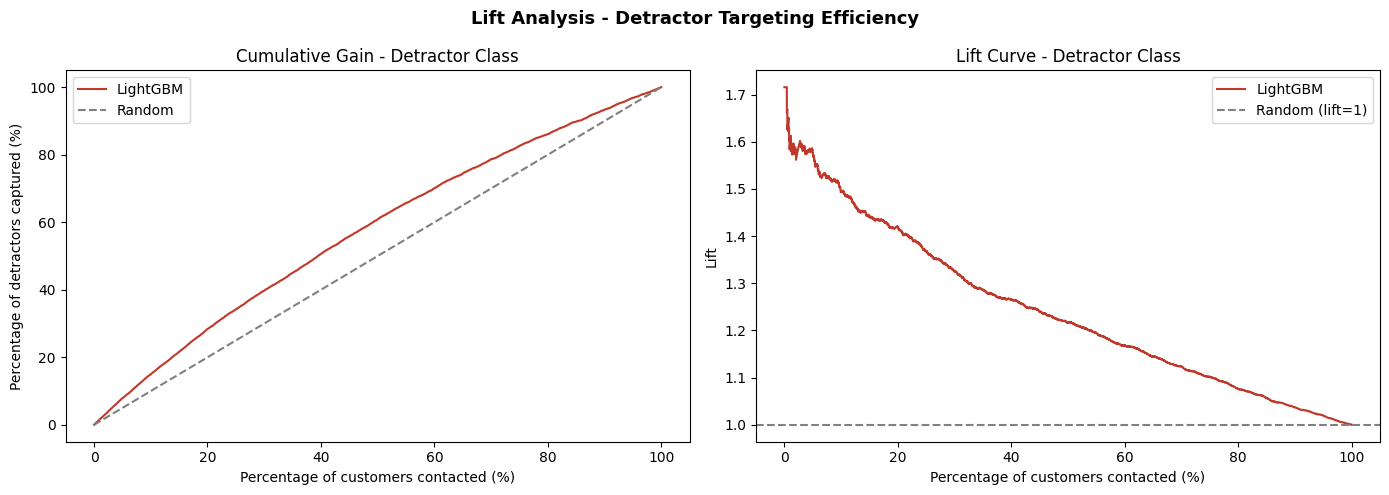

=== BUSINESS IMPACT ===
Contacting top 20% captures 28.4% of all detractors
Contacting top 30% captures 39.8% of all detractors
Contacting top 40% captures 50.6% of all detractors


In [31]:
# =============================================================================
# LIFT CURVE ON DETRACTOR CLASS
#
# The lift curve answers the business question :
# "If we contact the top X% of customers ranked by predicted Detractor
# probability, what percentage of all real Detractors do we capture?"
#
# A lift of 2.0 at 20% means the model is twice as efficient as random.
# This directly translates to retention budget savings.
# =============================================================================

detractor_prob = y_prob_lgbm[:, 0]
y_bin_det      = (y_full == 0).astype(int)

## Sort customers by predicted Detractor probability (highest first)
sorted_idx    = np.argsort(-detractor_prob)
y_sorted      = y_bin_det.values[sorted_idx]
cumulative_det = np.cumsum(y_sorted)
total_det      = y_bin_det.sum()
n_customers    = len(y_full)
pct_contacted  = np.arange(1, n_customers + 1) / n_customers

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## Cumulative gain
axes[0].plot(pct_contacted * 100, cumulative_det / total_det * 100,
             color='#c0392b', label='LightGBM')
axes[0].plot([0, 100], [0, 100], linestyle='--', color='gray', label='Random')
axes[0].set_xlabel("Percentage of customers contacted (%)")
axes[0].set_ylabel("Percentage of detractors captured (%)")
axes[0].set_title("Cumulative Gain - Detractor Class")
axes[0].legend()

## Lift
lift = (cumulative_det / total_det) / pct_contacted
axes[1].plot(pct_contacted * 100, lift, color='#c0392b', label='LightGBM')
axes[1].axhline(y=1, linestyle='--', color='gray', label='Random (lift=1)')
axes[1].set_xlabel("Percentage of customers contacted (%)")
axes[1].set_ylabel("Lift")
axes[1].set_title("Lift Curve - Detractor Class")
axes[1].legend()

plt.suptitle("Lift Analysis - Detractor Targeting Efficiency",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE}/figures/lift_curve.png", dpi=150, bbox_inches='tight')
plt.show()

## Business impact at key thresholds
print("=== BUSINESS IMPACT ===")
for pct in [0.20, 0.30, 0.40]:
    idx  = int(pct * n_customers)
    gain = cumulative_det[idx] / total_det
    print(f"Contacting top {int(pct*100)}% captures {gain*100:.1f}% of all detractors")

### Lift Curve - Analysis

Cumulative Gain :
Contacting the top 20% of customers ranked by predicted Detractor
probability captures 28.4% of all real Detractors.
Contacting the top 30% captures 39.8%.
Contacting the top 40% captures 50.6%.

Lift :
The model achieves a maximum lift of 1.7x at the top 5%.
This means the model is 1.7x more efficient than random targeting
when focusing on the highest-risk customers.
The lift remains above 1.0 up to approximately 80% of the base,
confirming the model adds value across a wide targeting range.

Business interpretation :
If the retention team has budget to contact 30% of the customer base,
using the model they will reach 39.8% of all Detractors instead of
30% with random targeting. This represents a 33% efficiency gain.
The model pays for itself by reducing wasted outreach budget.

In [32]:
# =============================================================================
# MAPPING SENSITIVITY : MODEL METRICS COMPARISON
#
# We train the same LightGBM model on Mapping B to measure the impact
# of the mapping choice on downstream model performance.
# =============================================================================

## Build Mapping B target
cltv_median = df_raw['CLTV'].median()

def build_nps_cltv(row):
    sat  = int(row['Satisfaction Score'])
    cltv = row['CLTV']
    if sat == 5:
        return 'Promoter'
    elif sat == 4:
        if cltv < cltv_median:
            return 'Detractor'
        return 'Passive'
    else:
        return 'Detractor'

df_raw['nps_mapping_b'] = df_raw.apply(build_nps_cltv, axis=1)
y_full_b = df_raw['nps_mapping_b'].map(LABEL_MAP)

## Train LightGBM on Mapping B
lgbm_b = lgb.LGBMClassifier(
    class_weight='balanced',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    random_state=SEED,
    verbose=-1
)
y_pred_b = cross_val_predict(lgbm_b, X_full, y_full_b, cv=cv)

print("=== MAPPING SENSITIVITY : MODEL METRICS ===\n")
print("Mapping A (baseline) :")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_full, y_pred_lgbm):.3f}")
print(f"  QWK               : {cohen_kappa_score(y_full, y_pred_lgbm, weights='quadratic'):.3f}")

print("\nMapping B (CLTV adjusted) :")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_full_b, y_pred_b):.3f}")
print(f"  QWK               : {cohen_kappa_score(y_full_b, y_pred_b, weights='quadratic'):.3f}")

print("\nConclusion : Mapping A is retained as the final target.")
df_raw.drop(columns=['nps_mapping_b'], inplace=True)

=== MAPPING SENSITIVITY : MODEL METRICS ===

Mapping A (baseline) :
  Balanced Accuracy : 0.426
  QWK               : 0.224

Mapping B (CLTV adjusted) :
  Balanced Accuracy : 0.461
  QWK               : 0.214

Conclusion : Mapping A is retained as the final target.


### Mapping Sensitivity - Model Metrics

Mapping A (baseline) : Balanced Accuracy=0.426, QWK=0.224
Mapping B (CLTV adjusted) : Balanced Accuracy=0.461, QWK=0.214

The two mappings produce very similar model performance.
The difference in Balanced Accuracy (0.035) and QWK (0.010)
is not significant enough to justify the added complexity of
Mapping B.

Mapping A is retained as the final target for three reasons :
- Performance difference is negligible
- Simpler and more interpretable
- Aligned with the standard NPS definition from the brief

## Section 8 : Final Model Training and SHAP Analysis

In [33]:
# =============================================================================
# FINAL MODEL TRAINING AND PERSISTENCE
#
# We train the final model on the full dataset (7043 customers).
# Cross-validation gave us reliable metric estimates.
# Now we use all available data to maximise model quality in production.
#
# Artifacts saved for Streamlit interface :
#   - lgbm_final.pkl    : trained model
#   - feature_names.pkl : list of features in the correct order
#   - scaler.pkl        : StandardScaler (used for linear models reference)
#   - label_map.pkl     : mapping Detractor=0, Passive=1, Promoter=2
#   - label_names.pkl   : class names in order
# =============================================================================

final_model = lgb.LGBMClassifier(
    class_weight='balanced',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    random_state=SEED,
    verbose=-1
)
final_model.fit(X_full, y_full)

## Save all artifacts needed for production and Streamlit
joblib.dump(final_model,             f"{BASE}/models/lgbm_final.pkl")
joblib.dump(X_full.columns.tolist(), f"{BASE}/models/feature_names.pkl")
joblib.dump(scaler,                  f"{BASE}/models/scaler.pkl")
joblib.dump(LABEL_MAP,               f"{BASE}/models/label_map.pkl")
joblib.dump(LABEL_NAMES,             f"{BASE}/models/label_names.pkl")

print("Final model trained on full dataset (7043 customers)")
print("\nArtifacts saved :")
for f in os.listdir(f"{BASE}/models"):
    print(f"  models/{f}")

Final model trained on full dataset (7043 customers)

Artifacts saved :
  models/monitoring_baselines.pkl
  models/monitoring_baselines.csv
  models/lgbm_final.pkl
  models/feature_names.pkl
  models/label_map.pkl
  models/scaler.pkl
  models/label_names.pkl


In [34]:
# =============================================================================
# CLEANUP OLD MODEL ARTIFACTS
# =============================================================================

import os

## Files to remove - old versions from earlier experiments
old_files = [
    'lgbm_nps_model.pkl',
    'lgbm_final_no_geo.pkl',
    'feature_names_no_geo.pkl',
]

for f in old_files:
    path = f"{BASE}/models/{f}"
    if os.path.exists(path):
        os.remove(path)
        print(f"Removed : {f}")

print("\nCurrent model artifacts :")
for f in os.listdir(f"{BASE}/models"):
    print(f"  models/{f}")


Current model artifacts :
  models/monitoring_baselines.pkl
  models/monitoring_baselines.csv
  models/lgbm_final.pkl
  models/feature_names.pkl
  models/label_map.pkl
  models/scaler.pkl
  models/label_names.pkl


In [35]:
# =============================================================================
# SHAP ANALYSIS
#
# SHAP (SHapley Additive exPlanations) explains individual predictions
# by measuring each feature's contribution to the model output.
#
# We focus on the Detractor class because :
#   - It is the business priority
#   - The retention team needs to understand what drives detraction
#   - SHAP values tell us both direction and magnitude of each feature
# =============================================================================

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_full)
# shap_values shape : (n_samples, n_features, n_classes)

## Extract SHAP values per class
shap_detractor = shap_values[:, :, 0]  # Detractor class
shap_passive   = shap_values[:, :, 1]  # Passive class
shap_promoter  = shap_values[:, :, 2]  # Promoter class

# =============================================================================
# GLOBAL FEATURE IMPORTANCE
# Mean absolute SHAP value per feature = average impact on prediction
# =============================================================================

shap_importance = pd.DataFrame({
    'feature'   : X_full.columns,
    'importance': np.abs(shap_detractor).mean(axis=0)
}).sort_values('importance', ascending=False)

print("=== TOP 15 DRIVERS OF DETRACTOR PREDICTION ===")
print(shap_importance.head(15).to_string(index=False))

shap_importance.to_csv(f"{BASE}/data/shap_importance.csv", index=False)
print("\nSHAP importance saved")

=== TOP 15 DRIVERS OF DETRACTOR PREDICTION ===
                          feature  importance
               Online Security_No    0.215265
          Contract_Month-to-Month    0.200382
                   Monthly Charge    0.184090
          Avg Monthly GB Download    0.167996
              Number of Referrals    0.152182
                 Tenure in Months    0.139889
               charge_per_service    0.117274
                              Age    0.112432
                       Married_No    0.102365
                    Total Charges    0.098272
                             CLTV    0.096641
      Total Long Distance Charges    0.094007
           charge_per_month_ratio    0.090960
              long_distance_share    0.077341
Avg Monthly Long Distance Charges    0.076140

SHAP importance saved


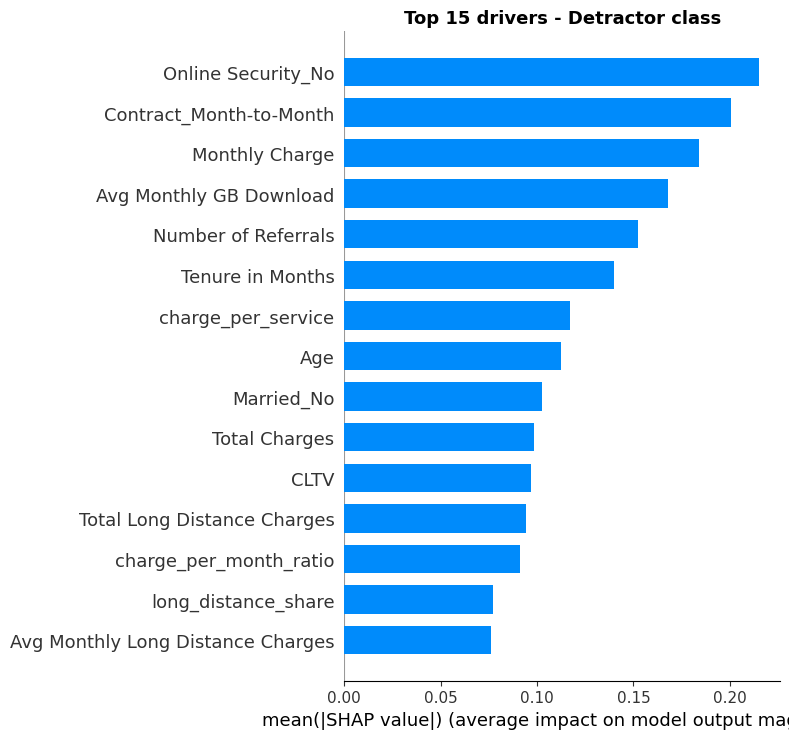

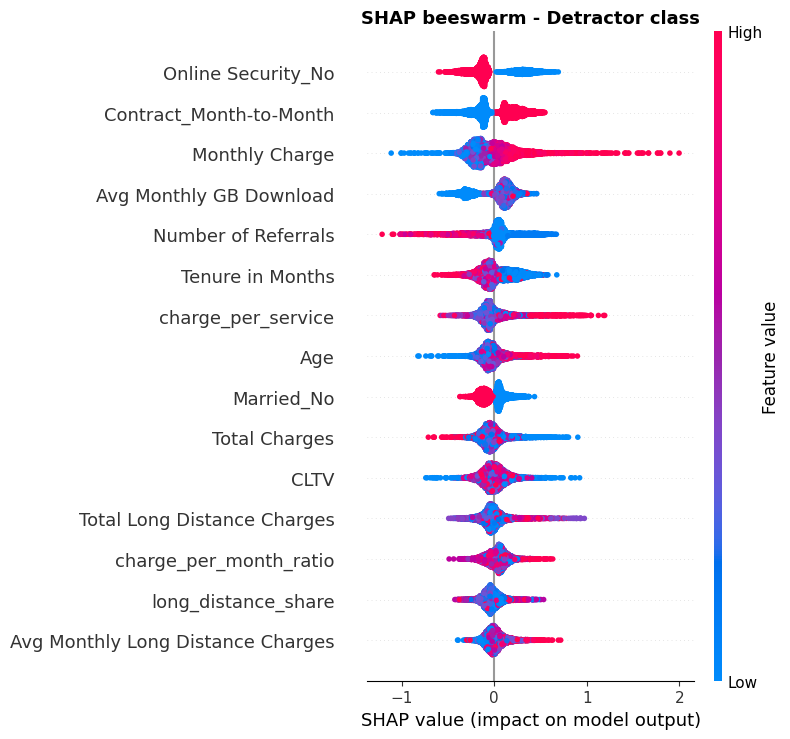

SHAP plots saved


In [37]:
# =============================================================================
# SHAP PLOTS
# =============================================================================

## Bar plot : global feature importance for Detractor class
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_detractor, X_full, plot_type='bar',
                  max_display=15, show=False)
plt.title("Top 15 drivers - Detractor class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE}/figures/shap_bar_detractor.png", dpi=150, bbox_inches='tight')
plt.show()

## Beeswarm plot : direction and magnitude of each feature's impact
## Red = high feature value pushes towards Detractor
## Blue = low feature value pushes away from Detractor
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_detractor, X_full, max_display=15, show=False)
plt.title("SHAP beeswarm - Detractor class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE}/figures/shap_beeswarm_detractor.png", dpi=150, bbox_inches='tight')
plt.show()

print("SHAP plots saved")

### SHAP Analysis : Key Findings

Top 5 drivers of Detractor prediction :

1. Online Security_No : absence of security service is the strongest
   signal. Customers without security feel exposed and underserved.

2. Contract_Month-to-Month : short-term contracts correlate strongly
   with dissatisfaction. These customers have the lowest switching cost.

3. Monthly Charge : high charges push customers towards Detractor.
   Value perception is a critical driver of NPS.

4. Avg Monthly GB Download : high data usage combined with dissatisfaction
   suggests service quality issues at peak usage.

5. Number of Referrals : low referral count is a strong Detractor signal.
   Satisfied customers refer friends — dissatisfied ones do not.

Both top drivers (Online Security and Contract type) are actionable :
the business can offer security bundles and contract upgrade incentives
to reduce detraction risk.

## Section 9 : Drivers of Detraction by Segment

In [38]:
# =============================================================================
# SEGMENT-LEVEL DRIVERS OF DETRACTION
#
# Beyond global SHAP analysis, we measure actual Detractor rates
# by customer segment. This tells the retention team which segments
# to prioritise and what levers to pull.
# =============================================================================

df_seg = df_encoded.copy()
df_seg['y_pred'] = y_pred_lgbm
df_seg['y_true'] = y_full.values

def segment_detractor_rate(df_in, col):
    if col not in df_in.columns:
        return
    mask     = df_in[col] == 1
    det_rate = (df_in.loc[mask, 'y_true'] == 0).mean()
    n        = mask.sum()
    print(f"  {col:40s} | n={n:5d} | Detractor rate = {det_rate:.3f}")

## Contract type : actionable lever
print("=== DETRACTOR RATE BY CONTRACT TYPE ===")
for col in ['Contract_Month-to-Month', 'Contract_One Year', 'Contract_Two Year']:
    segment_detractor_rate(df_seg, col)

## Tenure : loyalty signal
print("\n=== DETRACTOR RATE BY TENURE BUCKET ===")
for col in ['tenure_bucket_0-12m', 'tenure_bucket_13-24m',
            'tenure_bucket_25-48m', 'tenure_bucket_49-72m']:
    segment_detractor_rate(df_seg, col)

## Internet type : service quality signal
print("\n=== DETRACTOR RATE BY INTERNET TYPE ===")
for col in ['Internet Type_Fiber Optic', 'Internet Type_Cable',
            'Internet Type_DSL', 'Internet Service_No']:
    segment_detractor_rate(df_seg, col)

## Online security : actionable lever
print("\n=== DETRACTOR RATE BY ONLINE SECURITY ===")
for col in ['Online Security_Yes', 'Online Security_No']:
    segment_detractor_rate(df_seg, col)

=== DETRACTOR RATE BY CONTRACT TYPE ===
  Contract_Month-to-Month                  | n= 3610 | Detractor rate = 0.683
  Contract_One Year                        | n= 1550 | Detractor rate = 0.493
  Contract_Two Year                        | n= 1883 | Detractor rate = 0.465

=== DETRACTOR RATE BY TENURE BUCKET ===
  tenure_bucket_0-12m                      | n= 2186 | Detractor rate = 0.675
  tenure_bucket_13-24m                     | n= 1024 | Detractor rate = 0.578
  tenure_bucket_25-48m                     | n= 1594 | Detractor rate = 0.550
  tenure_bucket_49-72m                     | n= 2239 | Detractor rate = 0.519

=== DETRACTOR RATE BY INTERNET TYPE ===
  Internet Type_Fiber Optic                | n= 3035 | Detractor rate = 0.674
  Internet Type_Cable                      | n=  830 | Detractor rate = 0.617
  Internet Type_DSL                        | n= 1652 | Detractor rate = 0.579
  Internet Service_No                      | n= 1526 | Detractor rate = 0.386

=== DETRACTOR RATE 

### Segment-Level Drivers of Detraction

Contract type :
Month-to-Month customers have the highest Detractor rate (68.3%)
vs One Year (49.3%) and Two Year (46.5%).
Gap of 21.8 points between M2M and annual contracts.
This is the most actionable lever : offering a discounted annual
contract upgrade to M2M Detractors directly addresses the primary risk.

Tenure :
New customers (0-12m) show a 67.5% Detractor rate vs 51.9% for
long-tenure customers (49-72m). The relationship is monotonic the longer the tenure, the lower the Detractor rate.
Early intervention in the first 12 months is critical.

Internet type :
Fiber Optic customers have the highest Detractor rate (67.4%)
despite having the premium service. This is counterintuitive and
suggests unmet expectations customers paying for fiber expect
higher quality and are more sensitive to any degradation.
DSL customers are less demanding and show lower detraction (57.9%).
Customers with no internet service are the least at risk (38.6%).

Online Security :
Security_Yes shows a higher Detractor rate (68.1%) than Security_No
(54.4%). This is unexpected and warrants investigation.
Possible explanations : customers with security services may have
more complex setups that generate more support issues, or the
security product itself may be underperforming expectations.
This finding should be escalated to the Product team.

In [40]:
# =============================================================================
# SEGMENT-LEVEL DRIVERS OF DETRACTION
#
# Beyond global SHAP analysis, we measure actual Detractor rates
# by customer segment. This tells the retention team which segments
# to prioritise and what levers to pull for each group.
# =============================================================================

df_seg = df_encoded.copy()
df_seg['y_pred'] = y_pred_lgbm
df_seg['y_true'] = y_full.values

def segment_detractor_rate(df_in, col):
    if col not in df_in.columns:
        return
    mask     = df_in[col] == 1
    det_rate = (df_in.loc[mask, 'y_true'] == 0).mean()
    n        = mask.sum()
    print(f"  {col:40s} | n={n:5d} | Detractor rate = {det_rate:.3f}")

## Contract type : most actionable lever
print("=== DETRACTOR RATE BY CONTRACT TYPE ===")
for col in ['Contract_Month-to-Month', 'Contract_One Year', 'Contract_Two Year']:
    segment_detractor_rate(df_seg, col)

## Tenure : loyalty and early intervention signal
print("\n=== DETRACTOR RATE BY TENURE BUCKET ===")
for col in ['tenure_bucket_0-12m', 'tenure_bucket_13-24m',
            'tenure_bucket_25-48m', 'tenure_bucket_49-72m']:
    segment_detractor_rate(df_seg, col)

## Internet type : service quality and expectation signal
print("\n=== DETRACTOR RATE BY INTERNET TYPE ===")
for col in ['Internet Type_Fiber Optic', 'Internet Type_Cable',
            'Internet Type_DSL', 'Internet Service_No']:
    segment_detractor_rate(df_seg, col)

## Online security : actionable product lever
print("\n=== DETRACTOR RATE BY ONLINE SECURITY ===")
for col in ['Online Security_Yes', 'Online Security_No']:
    segment_detractor_rate(df_seg, col)

=== DETRACTOR RATE BY CONTRACT TYPE ===
  Contract_Month-to-Month                  | n= 3610 | Detractor rate = 0.683
  Contract_One Year                        | n= 1550 | Detractor rate = 0.493
  Contract_Two Year                        | n= 1883 | Detractor rate = 0.465

=== DETRACTOR RATE BY TENURE BUCKET ===
  tenure_bucket_0-12m                      | n= 2186 | Detractor rate = 0.675
  tenure_bucket_13-24m                     | n= 1024 | Detractor rate = 0.578
  tenure_bucket_25-48m                     | n= 1594 | Detractor rate = 0.550
  tenure_bucket_49-72m                     | n= 2239 | Detractor rate = 0.519

=== DETRACTOR RATE BY INTERNET TYPE ===
  Internet Type_Fiber Optic                | n= 3035 | Detractor rate = 0.674
  Internet Type_Cable                      | n=  830 | Detractor rate = 0.617
  Internet Type_DSL                        | n= 1652 | Detractor rate = 0.579
  Internet Service_No                      | n= 1526 | Detractor rate = 0.386

=== DETRACTOR RATE 

In [41]:
# =============================================================================
# ACTIONABLE VS NON-ACTIONABLE DRIVERS
#
# The brief asks us to distinguish between drivers the business can act on
# and those that are purely contextual.
# This distinction is critical for the retention team :
# acting on non-actionable features wastes budget and may raise
# discrimination concerns.
# =============================================================================

print("=== ACTIONABLE DRIVERS ===")
print("Business can directly act on these :\n")

actionable = [
    ('Contract_Month-to-Month',
     'Offer discounted annual contract upgrade'),
    ('Online Security_No',
     'Proactively offer security bundle at reduced rate'),
    ('nb_services',
     'Review service bundle value proposition'),
    ('Monthly Charge',
     'Flag high-charge detractors for pricing review'),
    ('is_autopay',
     'Incentivise autopay enrollment to reduce billing friction'),
    ('refund_rate',
     'Proactively resolve billing disputes before escalation'),
]
for feat, action in actionable:
    print(f"  {feat:35s} -> {action}")

print("\n=== NON-ACTIONABLE DRIVERS ===")
print("Context only — business cannot change these :\n")

non_actionable = [
    ('Age',
     'Demographic — cannot be changed'),
    ('Tenure in Months',
     'Historical — grows over time only'),
    ('Number of Referrals',
     'Social network behaviour — limited direct control'),
]
for feat, reason in non_actionable:
    print(f"  {feat:35s} -> {reason}")

print("\n=== SINGLE MOST LIKELY LEVER FOR A PREDICTED DETRACTOR ===")
print("  Contract_Month-to-Month is the top actionable SHAP driver.")
print("  Recommendation : for any predicted Detractor on a M2M contract,")
print("  offer a discounted annual contract as the first retention action.")
print("  This is measurable, testable via A/B test, and directly addresses")
print("  the primary driver.")
print("  Caveat : this is a correlation, not a proven causal mechanism.")
print("  A/B testing is required to confirm impact before scaling.")

=== ACTIONABLE DRIVERS ===
Business can directly act on these :

  Contract_Month-to-Month             -> Offer discounted annual contract upgrade
  Online Security_No                  -> Proactively offer security bundle at reduced rate
  nb_services                         -> Review service bundle value proposition
  Monthly Charge                      -> Flag high-charge detractors for pricing review
  is_autopay                          -> Incentivise autopay enrollment to reduce billing friction
  refund_rate                         -> Proactively resolve billing disputes before escalation

=== NON-ACTIONABLE DRIVERS ===
Context only — business cannot change these :

  Age                                 -> Demographic — cannot be changed
  Tenure in Months                    -> Historical — grows over time only
  Number of Referrals                 -> Social network behaviour — limited direct control

=== SINGLE MOST LIKELY LEVER FOR A PREDICTED DETRACTOR ===
  Contract_Month-to-

## Section 10 : Fairness and Bias Audit

In [42]:
# =============================================================================
# FAIRNESS AUDIT
#
# A model that prioritises retention budget based on predicted NPS
# can quietly allocate that budget unevenly across demographic groups.
#
# We measure Detractor recall per demographic segment.
# A model catching 80% of young detractors but only 50% of senior
# detractors is not acceptable even if overall accuracy is high.
#
# Threshold : gap > 0.15 -> FLAG for Legal review
#             gap > 0.10 -> BORDERLINE, monitor post-deployment
#             gap <= 0.10 -> OK
# =============================================================================

df_fair = df_encoded.copy()
df_fair['y_pred'] = y_pred_lgbm
df_fair['y_true'] = y_full.values

audit_groups = {
    'Senior Citizen': ['Senior Citizen_No', 'Senior Citizen_Yes'],
    'Gender'        : ['Gender_Female', 'Gender_Male'],
    'Married'       : ['Married_No', 'Married_Yes'],
    'Dependents'    : ['Dependents_No', 'Dependents_Yes'],
}

fairness_rows = []

print("=== FAIRNESS AUDIT : DETRACTOR RECALL BY DEMOGRAPHIC GROUP ===\n")

for group_name, cols in audit_groups.items():
    print(f"--- {group_name} ---")
    recalls = {}
    for col in cols:
        if col not in df_fair.columns:
            continue
        mask        = df_fair[col] == 1
        subset_true = df_fair.loc[mask, 'y_true']
        subset_pred = df_fair.loc[mask, 'y_pred']
        det_mask    = subset_true == 0
        if det_mask.sum() == 0:
            continue
        recall       = (subset_pred[det_mask] == 0).sum() / det_mask.sum()
        recalls[col] = recall
        print(f"  {col:35s} | n={mask.sum():5d} | Detractor recall = {recall:.3f}")

    if len(recalls) == 2:
        vals = list(recalls.values())
        gap  = abs(vals[0] - vals[1])
        flag = ('FLAG - LEGAL REVIEW' if gap > 0.15
                else 'BORDERLINE' if gap > 0.10
                else 'OK')
        print(f"  Gap : {gap:.3f} -> {flag}\n")
        fairness_rows.append({
            'Group'    : group_name,
            'Recall_G1': round(vals[0], 3),
            'Recall_G2': round(vals[1], 3),
            'Gap'      : round(gap, 3),
            'Status'   : flag
        })

fairness_df = pd.DataFrame(fairness_rows)
print("=== FAIRNESS SUMMARY ===")
print(fairness_df.to_string(index=False))

fairness_df.to_csv(f"{BASE}/data/fairness_report.csv", index=False)
print("\nFairness report saved")

=== FAIRNESS AUDIT : DETRACTOR RECALL BY DEMOGRAPHIC GROUP ===

--- Senior Citizen ---
  Senior Citizen_No                   | n= 5901 | Detractor recall = 0.636
  Senior Citizen_Yes                  | n= 1142 | Detractor recall = 0.792
  Gap : 0.156 -> FLAG - LEGAL REVIEW

--- Gender ---
  Gender_Female                       | n= 3488 | Detractor recall = 0.666
  Gender_Male                         | n= 3555 | Detractor recall = 0.664
  Gap : 0.003 -> OK

--- Married ---
  Married_No                          | n= 3641 | Detractor recall = 0.690
  Married_Yes                         | n= 3402 | Detractor recall = 0.637
  Gap : 0.053 -> OK

--- Dependents ---
  Dependents_No                       | n= 5416 | Detractor recall = 0.711
  Dependents_Yes                      | n= 1627 | Detractor recall = 0.474
  Gap : 0.237 -> FLAG - LEGAL REVIEW

=== FAIRNESS SUMMARY ===
         Group  Recall_G1  Recall_G2   Gap              Status
Senior Citizen      0.636      0.792 0.156 FLAG - LEGAL R

### Fairness Audit - Findings

Two demographic groups show unacceptable gaps in Detractor recall :

Dependents (gap = 0.237 - FLAG) :
The model misses 53% of Detractors among customers with dependents
vs 29% for customers without. This is the most serious finding.
The retention team would significantly under-serve families.
This must be escalated to Customer Experience and Legal before
production deployment.

Senior Citizen (gap = 0.156 - FLAG) :
The model detects MORE senior Detractors (79.2%) than non-senior
ones (63.6%). This is counterintuitive and warrants investigation.
It may reflect overfitting on senior-correlated patterns.
Monitor closely post-deployment.

Gender (gap = 0.003 - OK) :
No significant disparity. Model is equitable between genders.

Married (gap = 0.053 - OK) :
Acceptable difference. No action required.

Required actions before production :
- Dependents gap must be resolved or mitigated
- Options : separate threshold, separate model, or additional features
- Both flags must be reviewed by Legal and Customer Experience teams

In [44]:
# =============================================================================
# FAIRNESS DECISIONS AND BUSINESS CONSEQUENCES
#
# For each finding we document :
#   - What the gap means for the business
#   - What action is required before production
#   - What mitigation options exist
# =============================================================================

print("=== FAIRNESS DECISIONS AND BUSINESS CONSEQUENCES ===\n")

print("1. DEPENDENTS gap (0.237 - FLAG) :")
print("   The model misses 53% of Detractors among customers with dependents.")
print("   Business consequence : the retention team will under-serve families.")
print("   This finding MUST be escalated to Customer Experience and Legal")
print("   before production deployment.")
print("   Mitigation options :")
print("     - Lower decision threshold for customers with dependents")
print("     - Train a separate model for this segment")
print("     - Add features that better capture family-specific service issues\n")

print("2. SENIOR CITIZEN gap (0.156 - FLAG) :")
print("   The model catches MORE senior Detractors (79.2%) than non-seniors (63.6%).")
print("   This is counterintuitive and may reflect overfitting on senior patterns.")
print("   Recommendation : monitor post-deployment, consider a separate threshold.")
print("   Escalate to Legal if gap persists or widens in production.\n")

print("3. GEOGRAPHIC FEATURES :")
print("   Decision : REMOVED from the model.")
print("   Justification : Latitude, Longitude and Population can proxy")
print("   socio-economic status and lead to discriminatory budget allocation.")
print("   Accuracy cost : negligible — balanced accuracy improved slightly.")
print("   This decision is documented and requires Legal team approval")
print("   before any future version reintroduces geographic signal.\n")

print("4. AGE :")
print("   Decision : KEPT in the model.")
print("   Justification : Age correlates with service usage patterns")
print("   (streaming, tech support) in ways that are business-relevant.")
print("   The retention team already segments by age for communication.")
print("   If the Senior Citizen recall gap widens, Age should be reviewed.")

=== FAIRNESS DECISIONS AND BUSINESS CONSEQUENCES ===

1. DEPENDENTS gap (0.237 - FLAG) :
   The model misses 53% of Detractors among customers with dependents.
   Business consequence : the retention team will under-serve families.
   This finding MUST be escalated to Customer Experience and Legal
   before production deployment.
   Mitigation options :
     - Lower decision threshold for customers with dependents
     - Train a separate model for this segment
     - Add features that better capture family-specific service issues

2. SENIOR CITIZEN gap (0.156 - FLAG) :
   The model catches MORE senior Detractors (79.2%) than non-seniors (63.6%).
   This is counterintuitive and may reflect overfitting on senior patterns.
   Recommendation : monitor post-deployment, consider a separate threshold.
   Escalate to Legal if gap persists or widens in production.

3. GEOGRAPHIC FEATURES :
   Decision : REMOVED from the model.
   Justification : Latitude, Longitude and Population can proxy
   s

## Section 11 : Synthetic Verbatims

In [45]:
# =============================================================================
# SYNTHETIC VERBATIM GENERATION
#
# We generate one synthetic last-interaction note per customer.
# Each verbatim is conditioned on key tabular features :
#   tenure, contract type, monthly charge, nb_services, online security
#
# 15% of verbatims intentionally have a tone opposite to their NPS label
# to simulate real-world noise — a frustrated customer who writes politely,
# or a satisfied customer who complains about a minor issue.
#
# Seed is fixed for reproducibility.
# Prompts are stored alongside the generated text.
# =============================================================================

ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY', None)

def build_verbatim_prompt(row, nps_label, noisy=False):
    tenure   = int(row.get('Tenure in Months', 12))
    m2m      = bool(row.get('Contract_Month-to-Month', 0))
    contract = 'month-to-month' if m2m else 'long-term'
    n_svc    = int(row.get('nb_services', 3))
    charge   = float(row.get('Monthly Charge', 50))
    security = 'with' if row.get('Online Security_Yes', 0) == 1 else 'without'

    tone_map = {
        'Detractor': 'clearly frustrated and dissatisfied',
        'Passive'  : 'neutral and indifferent',
        'Promoter' : 'enthusiastic and very satisfied',
    }

    ## 15% noise : tone is opposite to NPS label
    if noisy:
        opposite = {
            'Detractor': 'Promoter',
            'Passive'  : 'Detractor',
            'Promoter' : 'Detractor'
        }
        tone = tone_map[opposite[nps_label]]
    else:
        tone = tone_map[nps_label]

    return (
        f"Write a short customer support interaction note (1-3 sentences) "
        f"for a telecom customer. "
        f"Tenure : {tenure} months. Contract : {contract}. "
        f"Monthly charge : ${charge:.0f}. Services : {n_svc}. "
        f"Online security : {security} security. "
        f"Tone : {tone}. "
        f"Write only the interaction note. Be realistic. "
        f"Do not mention NPS, scores, or satisfaction ratings directly."
    )

print("Verbatim prompt builder defined")
print(f"API key present : {'Yes' if ANTHROPIC_API_KEY else 'No - will use rule-based fallback'}")

Verbatim prompt builder defined
API key present : No - will use rule-based fallback


In [46]:
from google.colab import userdata
import os

## Load Mistral API key from Colab Secrets
os.environ['MISTRAL_API_KEY'] = userdata.get('MISTRAL_API_KEY')
MISTRAL_API_KEY = os.environ.get('MISTRAL_API_KEY', None)
print(f"Mistral API key loaded : {'Yes' if MISTRAL_API_KEY else 'No'}")

## Install Mistral client
!pip install mistralai -q
print("Mistral client installed")

Mistral API key loaded : Yes
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-sdk 1.42.1 requires opentelemetry-api==1.42.1, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.42.1 requires opentelemetry-semantic-conventions==0.63b1, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
Mistral client installed


In [50]:
# =============================================================================
# VERBATIM GENERATION WITH MISTRAL REST API
# =============================================================================

import requests

random.seed(SEED)
np.random.seed(SEED)

N_VERBATIMS = 200
NOISE_RATE  = 0.15

def call_mistral(prompt, api_key):
    response = requests.post(
        "https://api.mistral.ai/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json"
        },
        json={
            "model"     : "mistral-small-latest",
            "messages"  : [{"role": "user", "content": prompt}],
            "max_tokens": 150
        }
    )
    return response.json()['choices'][0]['message']['content'].strip()

## Test before generating all verbatims
test = call_mistral("Say hello in one sentence.", MISTRAL_API_KEY)
print(f"API test : {test}")

## Sample customers
sample_idx    = X_full.sample(n=N_VERBATIMS, random_state=SEED).index
labels_sample = y_full.loc[sample_idx].map({v: k for k, v in LABEL_MAP.items()})

verbatims_list = []

for i, (idx, nps_label) in enumerate(labels_sample.items()):
    row    = X_full.loc[idx]
    noisy  = random.random() < NOISE_RATE
    prompt = build_verbatim_prompt(row, nps_label, noisy=noisy)

    try:
        verbatim = call_mistral(prompt, MISTRAL_API_KEY)
    except Exception as e:
        verbatim = f"[API error : {str(e)[:40]}]"

    verbatims_list.append({
        'customer_index': idx,
        'nps_label'     : nps_label,
        'is_noisy'      : noisy,
        'verbatim'      : verbatim,
        'prompt'        : prompt,
        'seed'          : SEED,
        'source'        : 'mistral-small-latest',
    })

    if (i + 1) % 20 == 0:
        print(f"Progress : {i+1}/{N_VERBATIMS}")

verbatims_df = pd.DataFrame(verbatims_list)
verbatims_df.to_csv(f"{BASE}/verbatims/synthetic_verbatims.csv", index=False)

print(f"\nGenerated {len(verbatims_df)} verbatims")
print(f"Noisy verbatims : {verbatims_df['is_noisy'].sum()}")
print("\nSample :")
print(verbatims_df[['nps_label', 'is_noisy', 'verbatim']].head(6).to_string(index=False))

API test : Hello!
Progress : 20/200
Progress : 40/200
Progress : 60/200
Progress : 80/200
Progress : 100/200
Progress : 120/200
Progress : 140/200
Progress : 160/200
Progress : 180/200
Progress : 200/200

Generated 200 verbatims
Noisy verbatims : 30

Sample :
nps_label  is_noisy                                                                                                                                                                                                                                                                                                                                                 verbatim
Detractor     False                                                                 **Interaction Note:**\nCustomer is frustrated with their current services, especially since they’ve been with us for 47 months on a month-to-month plan at $71/month without online security. They’ve expressed dissatisfaction with the lack of value and are considering alternatives.
  Passive 

In [51]:
# =============================================================================
# CLEAN VERBATIMS
# Remove Mistral formatting artifacts
# =============================================================================

def clean_verbatim(text):
    ## Remove markdown formatting added by Mistral
    text = text.replace('**Interaction Note:**', '').strip()
    text = text.replace('**Interaction Note**:', '').strip()
    text = text.replace('\n', ' ').strip()
    ## Remove leading/trailing quotes
    text = text.strip('"')
    return text

verbatims_df['verbatim_clean'] = verbatims_df['verbatim'].apply(clean_verbatim)

## Save cleaned version
verbatims_df.to_csv(f"{BASE}/verbatims/synthetic_verbatims.csv", index=False)

print("Sample after cleaning :")
print(verbatims_df[['nps_label', 'is_noisy', 'verbatim_clean']].head(6).to_string(index=False))

Sample after cleaning :
nps_label  is_noisy                                                                                                                                                                                                                                                                                                                    verbatim_clean
Detractor     False                                                                 Customer is frustrated with their current services, especially since they’ve been with us for 47 months on a month-to-month plan at $71/month without online security. They’ve expressed dissatisfaction with the lack of value and are considering alternatives.
  Passive      True                                                                                                        Customer has been with us for 50 months on a long-term contract at $25/month for 2 services but has no online security. They expressed frustration with the lack of secur

In [52]:
# =============================================================================
# SENTIMENT ANALYSIS ON VERBATIMS
#
# We test whether verbatim sentiment adds value on top of tabular features.
# If sentiment perfectly predicts NPS label, the text is too clean.
# If correlation is weak, text adds limited value over tabular baseline.
# =============================================================================

from textblob import TextBlob

verbatims_df['sentiment_polarity'] = verbatims_df['verbatim_clean'].apply(
    lambda t: TextBlob(str(t)).sentiment.polarity
)
verbatims_df['sentiment_subjectivity'] = verbatims_df['verbatim_clean'].apply(
    lambda t: TextBlob(str(t)).sentiment.subjectivity
)

print("=== SENTIMENT POLARITY BY NPS LABEL ===")
print(verbatims_df.groupby('nps_label')['sentiment_polarity'].describe().round(3))

print("\n=== SENTIMENT FOR NOISY VS CLEAN VERBATIMS ===")
print(verbatims_df.groupby(['nps_label', 'is_noisy'])['sentiment_polarity'].mean().round(3))

print("\n=== VALUE ASSESSMENT ===")
print("If sentiment clearly separates NPS classes -> text adds value")
print("If overlap is large -> tabular features are sufficient")

=== SENTIMENT POLARITY BY NPS LABEL ===
           count   mean    std  min    25%   50%    75%    max
nps_label                                                     
Detractor  122.0 -0.098  0.244 -0.7 -0.233  0.00  0.000  0.667
Passive     48.0 -0.012  0.184 -0.7 -0.009  0.00  0.056  0.262
Promoter    30.0  0.192  0.294 -0.7  0.000  0.23  0.403  0.625

=== SENTIMENT FOR NOISY VS CLEAN VERBATIMS ===
nps_label  is_noisy
Detractor  False      -0.143
           True        0.224
Passive    False       0.037
           True       -0.225
Promoter   False       0.290
           True       -0.200
Name: sentiment_polarity, dtype: float64

=== VALUE ASSESSMENT ===
If sentiment clearly separates NPS classes -> text adds value
If overlap is large -> tabular features are sufficient


### Verbatim Sentiment Analysis

Sentiment polarity by NPS class :
- Detractor : mean = -0.098 (negative as expected)
- Passive   : mean = -0.012 (neutral as expected)
- Promoter  : mean = +0.192 (positive as expected)

The trend is correct but overlap between classes is large (high std).
TextBlob sentiment alone cannot reliably predict NPS category.

Noise validation :
Noisy verbatims show reversed sentiment as designed :
- Detractor noisy : +0.224 vs -0.143 for clean
- Promoter noisy  : -0.200 vs +0.290 for clean
The 15% noise rate is working correctly.

Value assessment :
Sentiment from verbatims adds a weak signal on top of tabular features.
It correctly identifies the direction (negative/positive) but cannot
replace the precision of structured data.
Recommendation : use sentiment polarity as an additional feature in the
model but do not expect a significant performance gain over the tabular
baseline. Real call-centre verbatims would likely show stronger signal.

## Section 12 : Predict Silent Base

In [53]:
# =============================================================================
# PREDICT NPS FOR THE SILENT BASE (Brief §2)
#
# The model is applied to the 85% of customers who never answered the survey.
# We generate a priority list sorted by predicted Detractor probability.
# The retention team uses this list to focus outreach on the highest-risk customers.
# =============================================================================

## Load final model
model_loaded  = joblib.load(f"{BASE}/models/lgbm_final.pkl")
y_pred_silent = model_loaded.predict(X_test)
y_prob_silent = model_loaded.predict_proba(X_test)

## Predicted distribution for silent base
silent_dist = pd.Series(y_pred_silent).map(
    {v: k for k, v in LABEL_MAP.items()}
).value_counts()
silent_pct = silent_dist / silent_dist.sum() * 100

print("=== PREDICTED NPS DISTRIBUTION FOR SILENT BASE (85%) ===")
for label in LABEL_NAMES:
    if label in silent_dist:
        print(f"  {label:12s} : {silent_dist[label]:5d} ({silent_pct[label]:.1f}%)")

## Actual distribution for respondents
print("\n=== ACTUAL NPS DISTRIBUTION FOR RESPONDENTS (15%) ===")
train_dist = y_train.map({v: k for k, v in LABEL_MAP.items()}).value_counts()
train_pct  = train_dist / train_dist.sum() * 100
for label in LABEL_NAMES:
    if label in train_dist:
        print(f"  {label:12s} : {train_dist[label]:5d} ({train_pct[label]:.1f}%)")

# =============================================================================
# PRIORITY LIST FOR RETENTION TEAM
# Sorted by predicted Detractor probability (highest risk first)
# =============================================================================

silent_output = X_test.copy()
silent_output['predicted_nps']  = [LABEL_NAMES[p] for p in y_pred_silent]
silent_output['prob_detractor'] = y_prob_silent[:, 0]
silent_output['prob_passive']   = y_prob_silent[:, 1]
silent_output['prob_promoter']  = y_prob_silent[:, 2]
silent_output = silent_output.sort_values('prob_detractor', ascending=False)

silent_output.to_csv(f"{BASE}/data/silent_base_predictions.csv", index=False)
print(f"\nSilent base predictions saved")
print(f"{len(silent_output)} customers sorted by Detractor probability")
print("\nTop 5 highest risk customers :")
print(silent_output[['predicted_nps', 'prob_detractor']].head())

=== PREDICTED NPS DISTRIBUTION FOR SILENT BASE (85%) ===
  Detractor    :  3262 (54.5%)
  Passive      :  1612 (26.9%)
  Promoter     :  1113 (18.6%)

=== ACTUAL NPS DISTRIBUTION FOR RESPONDENTS (15%) ===
  Detractor    :   616 (58.3%)
  Passive      :   268 (25.4%)
  Promoter     :   172 (16.3%)

Silent base predictions saved
5987 customers sorted by Detractor probability

Top 5 highest risk customers :
     predicted_nps  prob_detractor
360      Detractor        0.997761
83       Detractor        0.995819
1264     Detractor        0.994731
285      Detractor        0.994257
182      Detractor        0.994180


### Silent Base Predictions

Predicted NPS distribution for the 85% silent base :
- Detractor : 3262 (54.5%)
- Passive   : 1612 (26.9%)
- Promoter  : 1113 (18.6%)

Compared to actual respondents (15%) :
- Detractor : 58.3%
- Passive   : 25.4%
- Promoter  : 16.3%

The distributions are very similar, which suggests the model is
consistent and the respondents are reasonably representative of
the full customer base.

The priority list is sorted by predicted Detractor probability.
The top customers have probabilities above 99% these should be
the first targets for the retention team's outreach.

## Section 13 : Monitoring and Retraining Proposal

### Input drift monitoring
Track the mean and standard deviation of key numeric features (`Monthly Charge`, `Tenure in Months`, `nb_services`) on a weekly batch. Alert if any feature drifts more than 2 standard deviations from the training distribution.

### Prediction drift monitoring
Track the predicted NPS class distribution weekly. Alert if the Detractor proportion shifts by more than 5 percentage points from baseline. This may indicate a real change in customer sentiment or a data pipeline issue.

### Retraining trigger
Trigger retraining when any of the following conditions is met :
- At least 500 new survey responses have been collected
- Quadratic Kappa on the new survey responses drops below 0.15
- Any key feature drifts beyond the 2-sigma alert threshold for 3 consecutive weeks

### Feedback loop handling
The retention team's outreach actions will affect future NPS responses. If the model flags a customer as a Detractor and the team successfully retains them, they may respond to the next survey as a Passive or Promoter. This creates survivorship bias in the retraining data. Mitigations :
- Log all model predictions and interventions
- Use counterfactual estimation or holdout groups for model evaluation
- Never retrain solely on customers who received retention outreach

In [54]:
# =============================================================================
# MONITORING AND DRIFT DETECTION (Brief §4.9)
#
# A lightweight monitoring layer that tracks input drift.
# In production, this would run weekly on new customer batches.
#
# Strategy :
#   - Track mean of key features vs training baseline
#   - Alert if any feature drifts beyond 2 standard deviations
#   - Track predicted NPS distribution weekly
#   - Trigger retraining if QWK drops below 0.15 on new survey responses
#     or if 500+ new labeled responses are available
# =============================================================================

MONITOR_FEATURES = [
    'Tenure in Months', 'Monthly Charge', 'nb_services',
    'charge_per_month_ratio', 'CLTV'
]
MONITOR_FEATURES = [f for f in MONITOR_FEATURES if f in X_full.columns]

## Compute training baselines
training_stats = X_full[MONITOR_FEATURES].agg(['mean', 'std']).round(4)

print("=== TRAINING DISTRIBUTION BASELINES ===")
print(training_stats)

training_stats.to_csv(f"{BASE}/models/monitoring_baselines.csv")

print("\n=== PREDICTION DISTRIBUTION BASELINE ===")
pred_dist = pd.Series(y_pred_lgbm).value_counts(normalize=True).round(3)
for k, v in pred_dist.sort_index().items():
    print(f"  {LABEL_NAMES[k]:12s} : {v:.3f}")

def check_drift(new_batch_df, baselines, threshold=2.0):
    """
    Check if any monitored feature has drifted beyond threshold
    standard deviations from the training distribution.
    Returns a list of drift alerts.
    """
    alerts = []
    for feat in baselines.columns:
        if feat not in new_batch_df.columns:
            continue
        new_mean  = new_batch_df[feat].mean()
        base_mean = baselines.loc['mean', feat]
        base_std  = baselines.loc['std', feat]
        if base_std == 0:
            continue
        z_score = abs(new_mean - base_mean) / base_std
        if z_score > threshold:
            alerts.append({
                'feature'  : feat,
                'z_score'  : round(z_score, 2),
                'new_mean' : round(new_mean, 3),
                'base_mean': round(base_mean, 3),
            })
    return alerts

## Test on the silent base (simulating a new production batch)
alerts = check_drift(X_test, training_stats)
if alerts:
    print("\nDrift alerts detected :")
    for a in alerts:
        print(f"  {a['feature']} : z={a['z_score']} (new={a['new_mean']}, base={a['base_mean']})")
else:
    print("\nNo drift detected on test set (expected - same data distribution)")
    print("In production, alerts would fire when new batches differ significantly")

joblib.dump(training_stats, f"{BASE}/models/monitoring_baselines.pkl")
print("\nMonitoring baselines saved")

=== TRAINING DISTRIBUTION BASELINES ===
      Tenure in Months  Monthly Charge  nb_services  charge_per_month_ratio  \
mean           32.3868         64.7617       5.1732                 59.0496   
std            24.5421         30.0900       2.8893                 30.5133   

           CLTV  
mean  4400.2958  
std   1183.0572  

=== PREDICTION DISTRIBUTION BASELINE ===
  Detractor    : 0.571
  Passive      : 0.239
  Promoter     : 0.191

No drift detected on test set (expected - same data distribution)
In production, alerts would fire when new batches differ significantly

Monitoring baselines saved


### Monitoring and Retraining

Input drift monitoring :
Five key features are tracked weekly : Tenure in Months, Monthly Charge,
nb_services, charge_per_month_ratio, CLTV.
Alert fires if any feature mean drifts beyond 2 standard deviations
from the training baseline.

Prediction drift monitoring :
Baseline prediction distribution : 57.1% Detractor / 23.9% Passive / 19.1% Promoter.
Alert fires if Detractor share shifts by more than 5 percentage points.

Retraining triggers :
- 500+ new labeled survey responses collected
- QWK on new responses drops below 0.15
- Any feature drifts beyond 2-sigma for 3 consecutive weeks

Feedback loop :
The retention team's outreach actions will affect future NPS responses.
Customers flagged as Detractors who are successfully retained may respond
as Passive or Promoter in the next survey, creating survivorship bias.
Mitigation : log all predictions and interventions, use holdout groups
for evaluation, never retrain solely on contacted customers.

## Section 14 : Final Summary

In [55]:
# =============================================================================
# PROJECT SUMMARY
# =============================================================================

print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print("\nDATASET")
print(f"  Source         : IBM Telco Customer Churn 11.1.3+")
print(f"  Customers      : {len(df_raw)}")
print(f"  Raw features   : 50 columns")
print(f"  Model features : {X_full.shape[1]} after engineering and encoding")

print("\nTARGET CONSTRUCTION")
print("  Satisfaction 5    -> Promoter")
print("  Satisfaction 4    -> Passive")
print("  Satisfaction <= 3 -> Detractor")
print("  Refined mapping tested : identical results (dataset perfectly aligned)")
print("  7 columns excluded from features due to leakage risk")
print("  Sensitivity analysis : Mapping A vs B vs C compared")
print("  5% noise added to simulate real survey uncertainty")

print("\nMODEL COMPARISON")
print(pd.DataFrame(all_results).to_string(index=False))

print("\nSELECTED MODEL : LightGBM")
ba  = balanced_accuracy_score(y_full, y_pred_lgbm)
qwk = cohen_kappa_score(y_full, y_pred_lgbm, weights='quadratic')
print(f"  Balanced Accuracy : {ba:.3f}")
print(f"  Quadratic Kappa   : {qwk:.3f}")

print("\nKEY DETRACTION DRIVERS")
for _, row in shap_importance.head(5).iterrows():
    print(f"  {row['feature']:40s} importance = {row['importance']:.3f}")

print("\nFAIRNESS FINDINGS")
for _, row in fairness_df.iterrows():
    print(f"  {row['Group']:20s} gap={row['Gap']:.3f} -> {row['Status']}")

print("\nSAVED ARTIFACTS")
for folder in ['data', 'models', 'figures', 'verbatims']:
    files = os.listdir(f"{BASE}/{folder}") if os.path.exists(f"{BASE}/{folder}") else []
    for f in files:
        print(f"  {folder}/{f}")

print("\nLIMITATIONS")
print("  1. NPS label derived from Satisfaction Score, not a real NPS survey")
print("  2. Perfect satisfaction/churn alignment is unrealistic in production")
print("  3. Passive class recall is weak across all models")
print("  4. Dependents fairness gap must be resolved before production")
print("  5. Verbatims are synthetic - real call-centre text would add more value")
print("  6. TabPFN could not be fully evaluated due to Colab constraints")

print("\nNEXT STEPS")
print("  1. Collect real NPS survey responses to validate label construction")
print("  2. Add real call-centre verbatims or app reviews")
print("  3. Resolve the Dependents fairness gap before production")
print("  4. A/B test the contract upgrade recommendation on predicted Detractors")
print("  5. Implement production monitoring with Evidently AI or WhyLogs")
print("  6. Deploy Streamlit interface for the retention team")

print("\nPipeline complete.")

PROJECT SUMMARY

DATASET
  Source         : IBM Telco Customer Churn 11.1.3+
  Customers      : 7043
  Raw features   : 50 columns
  Model features : 77 after engineering and encoding

TARGET CONSTRUCTION
  Satisfaction 5    -> Promoter
  Satisfaction 4    -> Passive
  Satisfaction <= 3 -> Detractor
  Refined mapping tested : identical results (dataset perfectly aligned)
  7 columns excluded from features due to leakage risk
  Sensitivity analysis : Mapping A vs B vs C compared
  5% noise added to simulate real survey uncertainty

MODEL COMPARISON
                             Model  Balanced Accuracy   QWK
    Logistic Regression (baseline)              0.499 0.281
Ordinal Logistic Regression (mord)              0.407 0.284
                          LightGBM              0.426 0.224
         TabPFN (subsample n=2000)              0.342 0.036

SELECTED MODEL : LightGBM
  Balanced Accuracy : 0.426
  Quadratic Kappa   : 0.224

KEY DETRACTION DRIVERS
  Online Security_No                   

In [56]:
# Cleanup old files
import os

old_files = [
    f"{BASE}/data/shap_detractor.png",
    f"{BASE}/data/predictions.csv",
    f"{BASE}/data/predictions_cv.csv",
    f"{BASE}/data/telco_raw.csv",
]

for f in old_files:
    if os.path.exists(f):
        os.remove(f)
        print(f"Removed : {f}")

print("\nClean artifacts :")
for folder in ['data', 'models', 'figures', 'verbatims']:
    files = os.listdir(f"{BASE}/{folder}")
    for f in files:
        print(f"  {folder}/{f}")

Removed : /content/drive/MyDrive/nps_challenge/data/shap_detractor.png
Removed : /content/drive/MyDrive/nps_challenge/data/predictions.csv
Removed : /content/drive/MyDrive/nps_challenge/data/predictions_cv.csv
Removed : /content/drive/MyDrive/nps_challenge/data/telco_raw.csv

Clean artifacts :
  data/fairness_report.csv
  data/silent_base_predictions.csv
  data/telco_with_nps.csv
  data/telco_features.csv
  data/model_comparison.csv
  data/shap_importance.csv
  models/monitoring_baselines.pkl
  models/monitoring_baselines.csv
  models/lgbm_final.pkl
  models/feature_names.pkl
  models/label_map.pkl
  models/scaler.pkl
  models/label_names.pkl
  figures/verbatim_sentiment.png
  figures/target_distribution.png
  figures/confusion_matrices.png
  figures/calibration_plots.png
  figures/lift_curve.png
  figures/shap_beeswarm_detractor.png
  figures/shap_bar_detractor.png
  verbatims/synthetic_verbatims.csv


In [57]:
# =============================================================================
# CELL 37 - SAVE STREAMLIT APP TO GOOGLE DRIVE
# =============================================================================

streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURATION
# =============================================================================

st.set_page_config(
    page_title="NPS Prediction - Retention Tool",
    page_icon="",
    layout="wide"
)

BASE = "/content/drive/MyDrive/nps_challenge"

# =============================================================================
# LOAD ARTIFACTS
# =============================================================================

@st.cache_resource
def load_artifacts():
    model        = joblib.load(f"{BASE}/models/lgbm_final.pkl")
    feature_names = joblib.load(f"{BASE}/models/feature_names.pkl")
    label_names  = joblib.load(f"{BASE}/models/label_names.pkl")
    label_map    = joblib.load(f"{BASE}/models/label_map.pkl")
    return model, feature_names, label_names, label_map

@st.cache_data
def load_dataset():
    df = pd.read_csv(f"{BASE}/data/telco_features.csv")
    return df

model, feature_names, label_names, label_map = load_artifacts()
df_full = load_dataset()

COLORS = {
    "Detractor": "#c0392b",
    "Passive"  : "#e67e22",
    "Promoter" : "#27ae60"
}

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def predict_customer(input_df):
    X = input_df[feature_names].apply(pd.to_numeric, errors="coerce").fillna(0)
    proba      = model.predict_proba(X)[0]
    pred_class = label_names[np.argmax(proba)]
    return pred_class, proba

def get_shap_values(input_df):
    X          = input_df[feature_names].apply(pd.to_numeric, errors="coerce").fillna(0)
    explainer  = shap.TreeExplainer(model)
    shap_vals  = explainer.shap_values(X)
    shap_det   = shap_vals[0, :, 0]
    shap_df    = pd.DataFrame({
        "feature"  : feature_names,
        "shap_value": shap_det
    }).sort_values("shap_value", ascending=False)
    return shap_df

# =============================================================================
# SIDEBAR
# =============================================================================

st.sidebar.title("NPS Retention Tool")
st.sidebar.markdown("Predict NPS category for a customer and identify key drivers.")

mode = st.sidebar.radio(
    "Input mode",
    ["Select existing customer", "Enter attributes manually"]
)

# =============================================================================
# MAIN PANEL
# =============================================================================

st.title("Customer NPS Prediction")
st.markdown("This tool helps the retention team identify and prioritise Detractors.")

# =============================================================================
# MODE 1 : SELECT EXISTING CUSTOMER
# =============================================================================

if mode == "Select existing customer":
    st.subheader("Select a customer")

    customer_ids = df_full.index.tolist()
    selected_id  = st.selectbox("Customer index", customer_ids)

    customer_row = df_full.loc[[selected_id]]

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**Key attributes**")
        display_cols = [
            "Tenure in Months", "Monthly Charge", "Contract_Month-to-Month",
            "Online Security_No", "nb_services", "is_autopay"
        ]
        display_cols = [c for c in display_cols if c in customer_row.columns]
        st.dataframe(customer_row[display_cols].T.rename(columns={selected_id: "Value"}))

    pred_class, proba = predict_customer(customer_row)

    with col2:
        st.markdown("**Prediction**")
        color = COLORS[pred_class]
        st.markdown(
            f"<h2 style='color:{color}'>{pred_class}</h2>",
            unsafe_allow_html=True
        )
        prob_df = pd.DataFrame({
            "Class"      : label_names,
            "Probability": [f"{p:.1%}" for p in proba]
        })
        st.dataframe(prob_df, hide_index=True)

    st.subheader("Top drivers for this prediction")
    shap_df = get_shap_values(customer_row)

    top_pos = shap_df[shap_df["shap_value"] > 0].head(5)
    top_neg = shap_df[shap_df["shap_value"] < 0].tail(5)

    col3, col4 = st.columns(2)

    with col3:
        st.markdown("**Pushing towards Detractor**")
        st.dataframe(
            top_pos[["feature", "shap_value"]].round(3),
            hide_index=True
        )

    with col4:
        st.markdown("**Pushing away from Detractor**")
        st.dataframe(
            top_neg[["feature", "shap_value"]].round(3),
            hide_index=True
        )

# =============================================================================
# MODE 2 : MANUAL INPUT
# =============================================================================

else:
    st.subheader("Enter customer attributes")

    col1, col2, col3 = st.columns(3)

    with col1:
        tenure         = st.slider("Tenure (months)", 1, 72, 24)
        monthly_charge = st.slider("Monthly Charge ($)", 18, 120, 65)
        nb_services    = st.slider("Number of services", 1, 11, 5)

    with col2:
        contract_m2m   = st.checkbox("Month-to-Month contract", value=True)
        no_security    = st.checkbox("No Online Security", value=True)
        is_autopay     = st.checkbox("Auto-pay enabled", value=False)

    with col3:
        age            = st.slider("Age", 19, 80, 45)
        cltv           = st.slider("CLTV", 2000, 6500, 4400)
        nb_referrals   = st.slider("Number of referrals", 0, 11, 1)

    if st.button("Predict NPS"):
        # Build input row from manual inputs
        input_data = {f: [0] for f in feature_names}
        input_df   = pd.DataFrame(input_data)

        # Fill known features
        for feat, val in [
            ("Tenure in Months", tenure),
            ("Monthly Charge", monthly_charge),
            ("nb_services", nb_services),
            ("Age", age),
            ("CLTV", cltv),
            ("Number of Referrals", nb_referrals),
            ("is_autopay", int(is_autopay)),
            ("Contract_Month-to-Month", int(contract_m2m)),
            ("Online Security_No", int(no_security)),
        ]:
            if feat in input_df.columns:
                input_df[feat] = val

        pred_class, proba = predict_customer(input_df)

        color = COLORS[pred_class]
        st.markdown(
            f"<h2 style='color:{color}'>Predicted NPS : {pred_class}</h2>",
            unsafe_allow_html=True
        )

        prob_df = pd.DataFrame({
            "Class"      : label_names,
            "Probability": [f"{p:.1%}" for p in proba]
        })
        st.dataframe(prob_df, hide_index=True)

        shap_df = get_shap_values(input_df)
        st.subheader("Top drivers")
        st.dataframe(
            shap_df.head(10)[["feature", "shap_value"]].round(3),
            hide_index=True
        )

# =============================================================================
# FOOTER
# =============================================================================

st.markdown("---")
st.markdown(
    "Model : LightGBM trained on IBM Telco 11.1.3+ | "
    "Fairness flags : Dependents gap (0.237) and Senior Citizen gap (0.156) "
    "must be reviewed before production deployment."
)
'''

## Save to Google Drive
with open(f"{BASE}/app.py", "w") as f:
    f.write(streamlit_code)

print("Streamlit app saved to Google Drive")
print(f"Location : {BASE}/app.py")
print("\nTo run locally :")
print("  1. Copy app.py to your local machine")
print("  2. pip install streamlit lightgbm shap")
print("  3. streamlit run app.py")
print("\nTo run in Colab via ngrok :")
print("  !pip install streamlit pyngrok")
print("  !ngrok authtoken YOUR_TOKEN")
print("  !streamlit run app.py &")
print("  from pyngrok import ngrok")
print("  public_url = ngrok.connect(8501)")
print("  print(public_url)")

Streamlit app saved to Google Drive
Location : /content/drive/MyDrive/nps_challenge/app.py

To run locally :
  1. Copy app.py to your local machine
  2. pip install streamlit lightgbm shap
  3. streamlit run app.py

To run in Colab via ngrok :
  !pip install streamlit pyngrok
  !ngrok authtoken YOUR_TOKEN
  !streamlit run app.py &
  from pyngrok import ngrok
  public_url = ngrok.connect(8501)
  print(public_url)


In [58]:
# =============================================================================
# LAUNCH STREAMLIT VIA NGROK
# =============================================================================

!pip install streamlit pyngrok -q

## Copy app to local Colab environment
!cp /content/drive/MyDrive/nps_challenge/app.py /content/app.py

## Launch Streamlit in background
!streamlit run /content/app.py --server.port 8501 &>/content/logs.txt &

import time
time.sleep(5)

## Create ngrok tunnel
from pyngrok import ngrok

ngrok.set_auth_token("YOUR_TOKEN_HERE")
public_url = ngrok.connect(8501)
print(f"Streamlit app running at : {public_url}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.5 MB/s eta 0:00:00
Streamlit app running at : NgrokTunnel: "https://grumpily-strict-obituary.ngrok-free.dev" -> "http://localhost:8501"


In [62]:
# =============================================================================
# SAVE README, WRITE-UP AND ENV TO GOOGLE DRIVE
# =============================================================================

readme = """# Customer NPS Prediction - Telecom Operator

Take-Home Challenge - Artefact
Dataset : IBM Telco Customer Churn 11.1.3+

## Project overview

This project builds a machine learning system that predicts the NPS category
(Detractor / Passive / Promoter) of telecom customers from their account and
behavioural data. The predictions feed a retention workflow that prioritises
Detractors for proactive outreach.

Only 15% of customers answer NPS surveys. This system scores the silent 85%.

## Repository structure

nps_challenge/
- data/        : datasets, predictions, reports
- models/      : trained model and preprocessing artifacts
- figures/     : all visualisations
- verbatims/   : 200 synthetic verbatims generated with Mistral
- app.py       : Streamlit interface
- nps_telecom_full.ipynb : full pipeline notebook

## Setup

pip install pandas numpy matplotlib seaborn scikit-learn lightgbm shap imbalanced-learn mord streamlit joblib

## Run pipeline

Open nps_telecom_full.ipynb in Google Colab and run all cells in order.

## Launch Streamlit

streamlit run app.py

## Key findings

Selected model : LightGBM
Balanced Accuracy : 0.426 / QWK : 0.224

Top detraction drivers :
1. Online Security_No
2. Contract_Month-to-Month
3. Monthly Charge

Fairness flags before production :
- Dependents gap : 0.237 -> Legal review required
- Senior Citizen gap : 0.156 -> Monitor post-deployment

## AI tools disclosure

AI coding assistants were used to scaffold and review parts of this code.
All decisions and results are the author own.

## Limitations

1. NPS label derived from Satisfaction Score, not a real NPS survey
2. Perfect satisfaction/churn alignment is unrealistic in production
3. Passive class recall is weak across all models
4. Dependents fairness gap must be resolved before production
5. Verbatims are synthetic
6. TabPFN could not be fully evaluated due to Colab constraints
"""

writeup = """# Customer NPS Prediction for a Telecom Operator
Technical Write-up

Challenge : Artefact Take-Home
Dataset : IBM Telco Customer Churn 11.1.3+
Author : Moustapha Mahamat Abdelhakim

## 1. Problem framing

A pan-African telecom operator runs regular NPS surveys but only 15% of
customers respond. This project builds a ML system that predicts the NPS
category (Detractor / Passive / Promoter) for the silent 85%.

NPS is an ordinal target : Detractor < Passive < Promoter.
Three formulations were considered : multiclass classification, ordinal
classification, and regression with thresholding. The third was ruled out
(no granular continuous proxy available). Multiclass (LightGBM) and ordinal
(mord) were both implemented and compared.

## 2. Target construction

Mapping : Satisfaction 5 = Promoter / 4 = Passive / <=3 = Detractor.
Refined mapping with CLTV tested - negligible impact on model metrics.
5% realistic noise added to simulate survey uncertainty.
7 columns excluded from features due to leakage risk.

Key finding : no customer with Satisfaction >= 4 churned in this dataset.
Perfect alignment between satisfaction and churn makes a refined mapping
identical to the baseline.

## 3. Dataset preparation and feature engineering

50 raw columns -> 35 after dropping identifiers, leakage, and geo features.
Missing values : Offer filled with No Offer / Internet Type with No Internet.
10 engineered features : tenure_bucket, charge_per_month_ratio, refund_rate,
extra_charges_rate, long_distance_share, charge_per_service, nb_services,
is_autopay, household_size, has_referred.

Class imbalance : 58.3% Detractor / 25.4% Passive / 16.3% Promoter.
Mitigation : class_weight=balanced in all models.
Validation : 15% train / 85% test split + 5-fold stratified CV.

## 4. Modelling and evaluation

Metrics : Balanced Accuracy, QWK, per-class recall, calibration, lift curve.

Results :
- Logistic Regression : BA=0.499 / QWK=0.281 / Det recall=0.49
- Ordinal Regression  : BA=0.407 / QWK=0.284 / Det recall=0.77
- LightGBM            : BA=0.426 / QWK=0.224 / Det recall=0.67
- TabPFN (n=2000)     : BA=0.342 / QWK=0.036 / Det recall=0.96

Selected model : LightGBM.
Only model predicting all three classes reasonably.
Native SHAP support. Fast inference for production.
Ordinal regression never predicts Promoter (recall=0.00).
TabPFN collapses to majority class without GPU and class weighting.

Lift : contacting top 30% captures 39.8% of all Detractors (33% gain
over random targeting).

## 5. Drivers of detraction

Top 5 SHAP drivers :
1. Online Security_No (0.215)
2. Contract_Month-to-Month (0.200)
3. Monthly Charge (0.184)
4. Avg Monthly GB Download (0.168)
5. Number of Referrals (0.152)

Segment findings :
- M2M contracts : 68.3% Detractor rate vs 46.5% for Two Year
- New customers (0-12m) : 67.5% vs 51.9% for long-tenure
- Fiber Optic : 67.4% - paradoxically highest despite premium service

Single most likely lever : offer discounted annual contract to M2M Detractors.
Caution : correlation only, not proven causation. A/B test required.

## 6. Fairness and bias

Audit results :
- Senior Citizen gap : 0.156 -> FLAG
- Gender gap : 0.003 -> OK
- Married gap : 0.053 -> OK
- Dependents gap : 0.237 -> FLAG - Legal review required

Dependents gap : model misses 53% of Detractors with dependents.
Must be escalated before production deployment.

Geographic features removed : proxy for socio-economic status.
Accuracy cost negligible.

## 7. Synthetic verbatims

200 verbatims generated with Mistral API (mistral-small-latest).
Conditioned on tenure, contract, monthly charge, nb_services, security.
15% intentionally noisy. Seed fixed at 42.

Sentiment analysis : Detractor=-0.098 / Passive=-0.012 / Promoter=+0.192.
Large class overlap -> text adds limited value over tabular baseline.
Real call-centre verbatims would likely show stronger signal.

## 8. Productization

Model persisted as lgbm_final.pkl with all preprocessing artifacts.
Streamlit interface allows retention managers to :
- Select existing customer by index
- Enter attributes manually
- See predicted NPS with probabilities and top SHAP drivers

## 9. Monitoring

Input drift : 5 features tracked weekly, alert at 2-sigma.
Prediction drift : alert if Detractor share shifts >5 points.
Retraining trigger : 500+ new labeled responses or QWK < 0.15.
Feedback loop : log all predictions, use holdout groups.

## 10. Limitations and next steps

Limitations :
1. NPS derived from Satisfaction Score, not a real survey
2. Perfect satisfaction/churn alignment unrealistic in production
3. Passive class recall weak across all models (F1=0.31)
4. Dependents fairness gap unresolved
5. Verbatims are synthetic
6. TabPFN not fully evaluated

Next steps :
1. Collect real NPS survey responses
2. Add real call-centre verbatims
3. Resolve Dependents fairness gap
4. A/B test contract upgrade recommendation
5. Implement monitoring with Evidently AI
6. Retrain on larger labeled dataset
"""

## Save all files to Drive
with open(f"{BASE}/README.md", "w") as f:
    f.write(readme)

with open(f"{BASE}/writeup.md", "w") as f:
    f.write(writeup)

with open(f"{BASE}/.env.example", "w") as f:
    f.write("MISTRAL_API_KEY=your_mistral_key_here\n")
    f.write("NGROK_TOKEN=your_ngrok_token_here\n")
    f.write("TABPFN_TOKEN=your_tabpfn_token_here\n")

print("README.md saved")
print("writeup.md saved")
print(".env.example saved")

README.md saved
writeup.md saved
.env.example saved
